In [17]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from statsmodels.nonparametric.smoothers_lowess import lowess
import warnings
warnings.filterwarnings("ignore", category=UserWarning)
warnings.filterwarnings("ignore", category=FutureWarning)

Using base path: /Users/vidhyakshayakannan/Documents/Temporal-Attention/data/averaged
Detected participants: ['addie', 'all_combined', 'angelyn', 'combined', 'jamshed', 'jill', 'lila', 'mahalakshmi', 'manaswini', 'navya', 'richard', 'sree', 'vidhya']
Columns after merge: ['Gap', 'addie', 'angelyn', 'jamshed', 'jill', 'lila', 'mahalakshmi', 'manaswini', 'navya', 'richard', 'sree', 'vidhya']


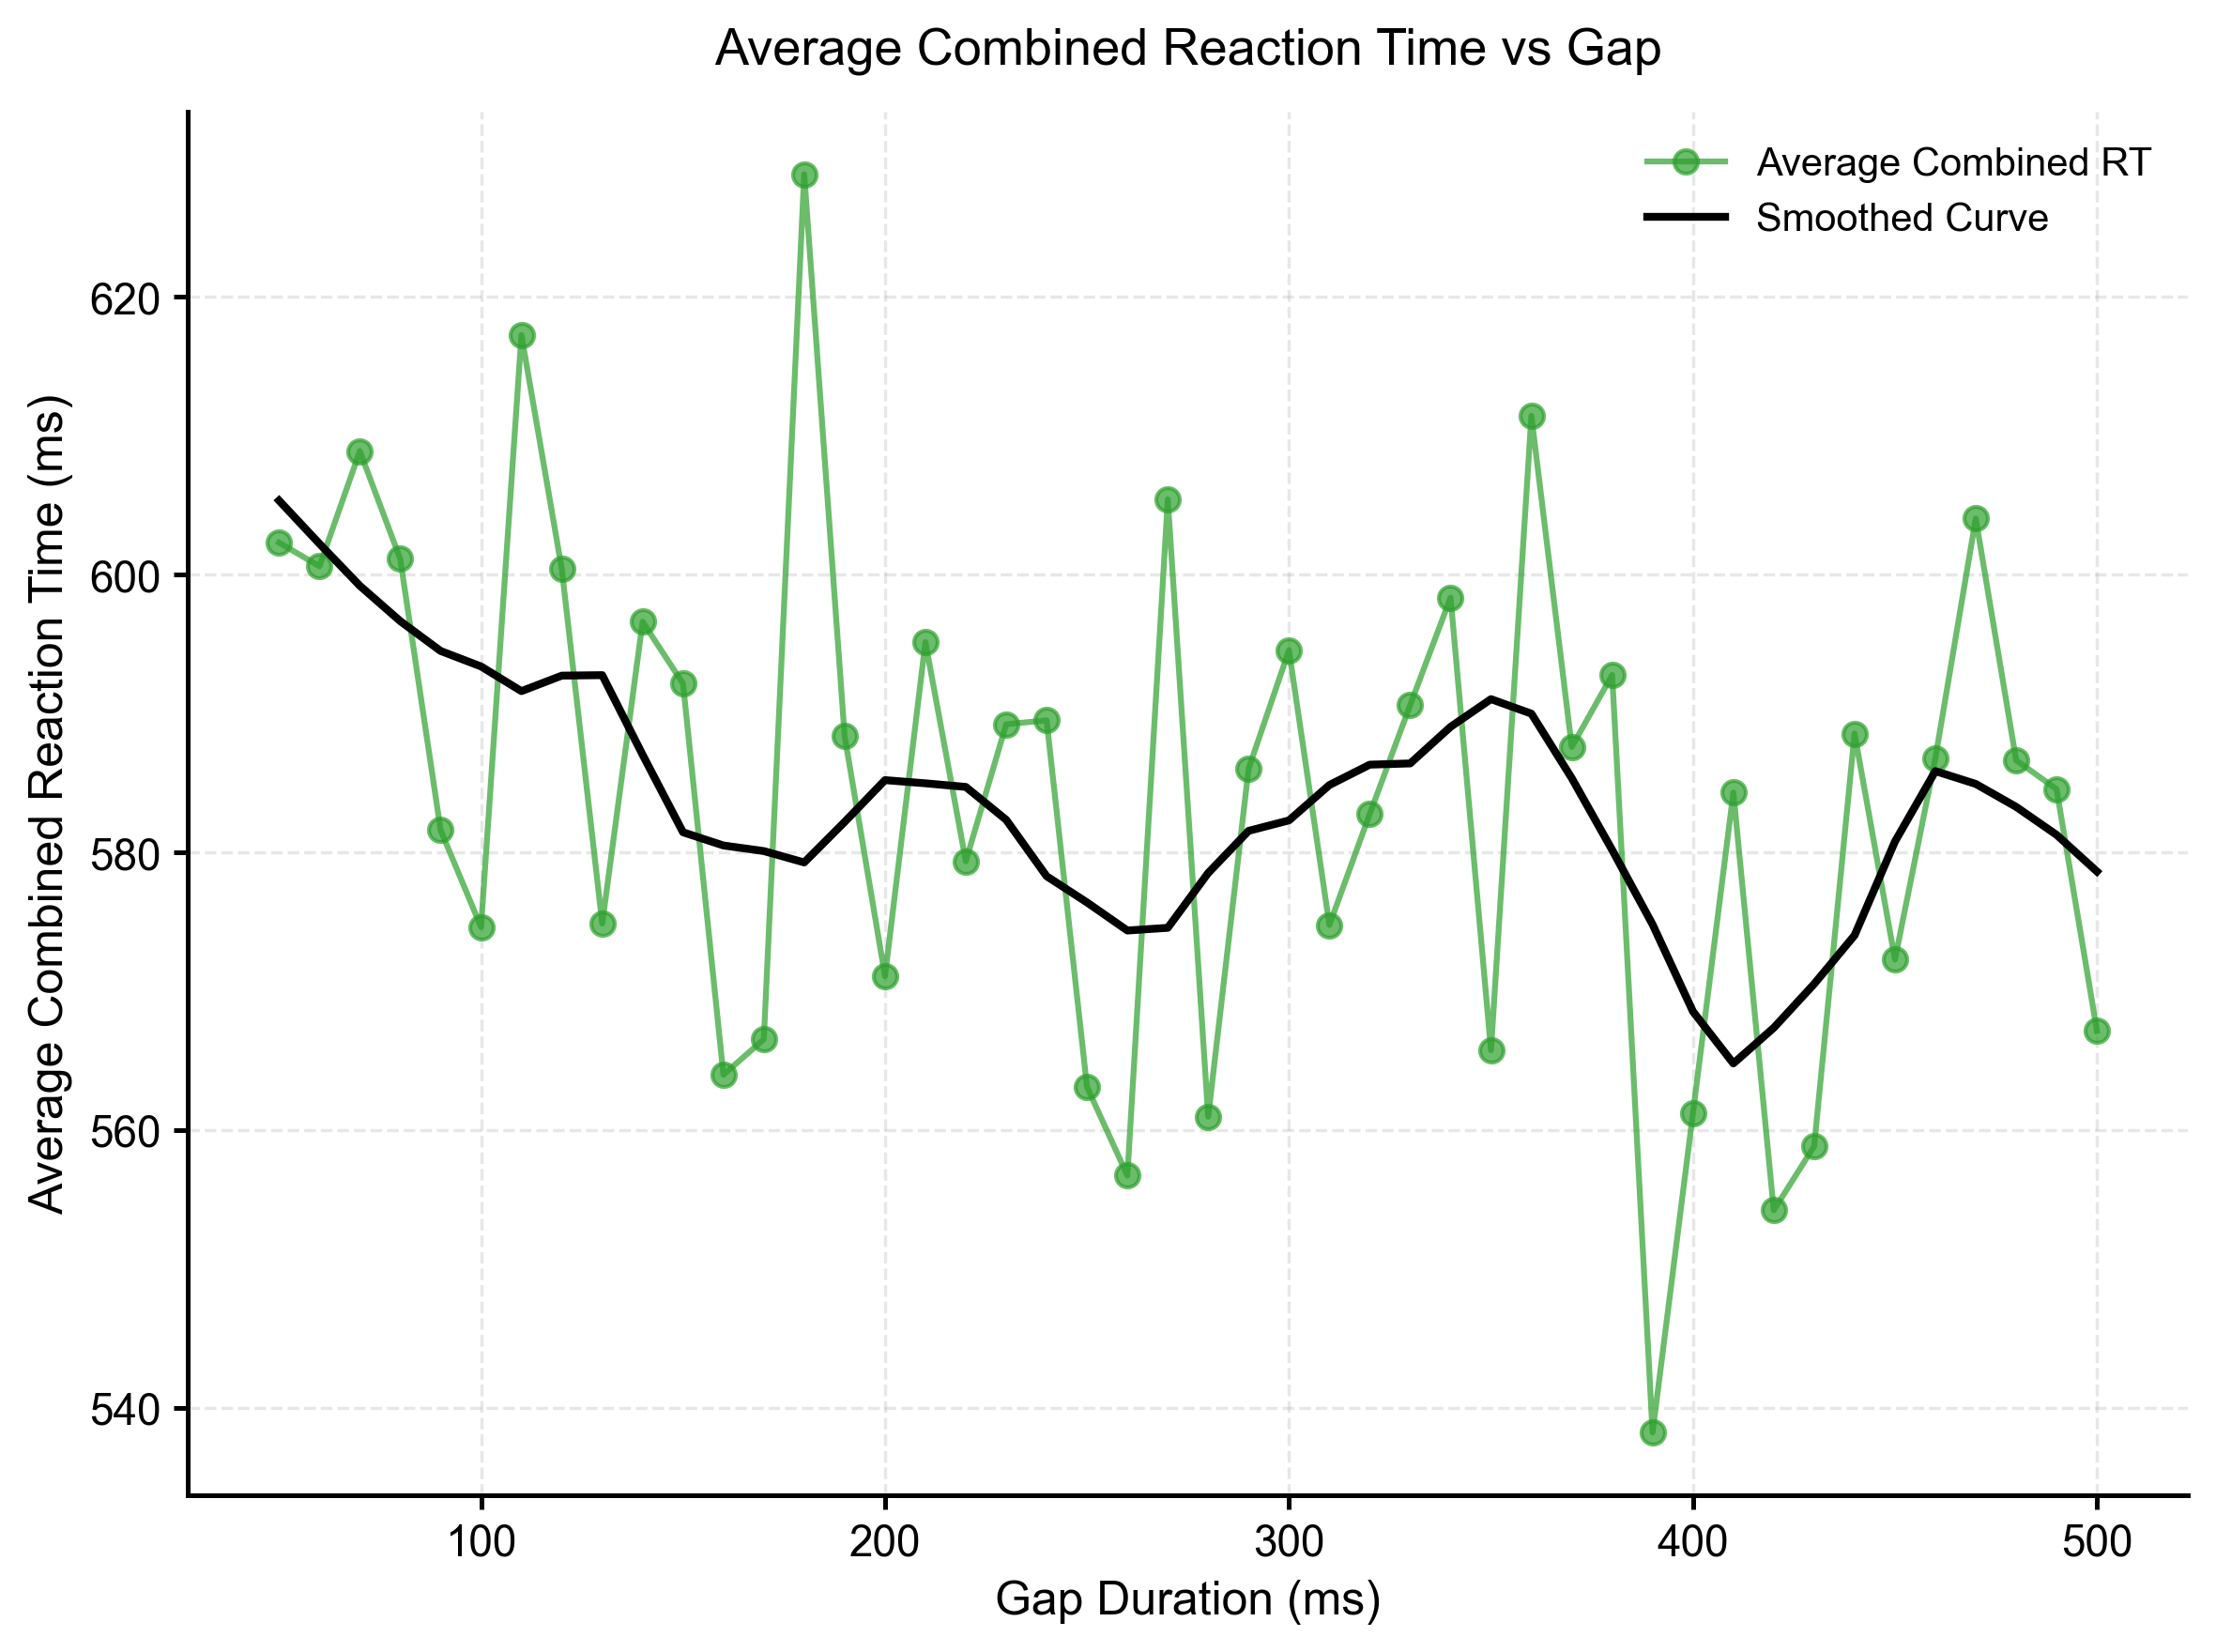


Saved plot to: graphs/avg_combined_rt_vs_gap.png


In [18]:
# ---------------- PLOT STYLE ---------------- #
plt.rcParams.update({
    'font.family': 'Arial',
    'font.size': 11,
    'axes.labelsize': 12,
    'axes.titlesize': 13,
    'xtick.labelsize': 11,
    'ytick.labelsize': 11,
    'legend.fontsize': 10,
    'figure.dpi': 300,
    'savefig.dpi': 300,
    'axes.linewidth': 1.2,
    'xtick.major.width': 1.2,
    'ytick.major.width': 1.2
})

# ---------------- SMART PROJECT ROOT DETECTION ---------------- #
cwd = Path.cwd()
for parent in [cwd] + list(cwd.parents):
    if parent.name == "Temporal-Attention":
        project_root = parent
        break

base_path = project_root / "data" / "averaged"
print(f"Using base path: {base_path}")
participants = sorted([p.name for p in base_path.iterdir() if p.is_dir()])
print(f"Detected participants: {participants}")

combined_data = []

# ---------------- LOAD AND MERGE ---------------- #
for participant in participants:
    csv_path = base_path / participant / f"{participant}_combinedavg.csv"
    
    if not csv_path.exists():
        continue
    
    df = pd.read_csv(csv_path)
    
    # Detect column that contains CombinedAvgRT or CombinedAveRT
    rt_col = next((c for c in df.columns if 'Combined' in c and 'RT' in c), None)
    
    if 'Gap' not in df.columns or rt_col is None:
        continue

    df = df[['Gap', rt_col]].copy()
    df.rename(columns={rt_col: participant}, inplace=True)
    combined_data.append(df)

if not combined_data:
    raise ValueError("No valid participant data found. Check file paths and CSV structure.")

# ---------------- MERGE ---------------- #
merged_df = combined_data[0]
for df in combined_data[1:]:
    merged_df = pd.merge(merged_df, df, on='Gap', how='inner')

print("Columns after merge:", merged_df.columns.tolist())

# ---------------- COMPUTE AVERAGE ---------------- #
valid_participants = [c for c in merged_df.columns if c in participants]
merged_df['AvgCombinedRT'] = merged_df[valid_participants].mean(axis=1)

# ---------------- SMOOTHING ---------------- #
smoothed = lowess(merged_df['AvgCombinedRT'], merged_df['Gap'], frac=0.2)

# ---------------- PLOT ---------------- #
fig, ax = plt.subplots(figsize=(8, 6))
color_avg = plt.get_cmap("tab10")(2)

ax.plot(merged_df['Gap'], merged_df['AvgCombinedRT'], 
        marker='o', color=color_avg, alpha=0.7, label='Average Combined RT')
ax.plot(smoothed[:, 0], smoothed[:, 1], 
        color='black', linewidth=2, label='Smoothed Curve')

ax.set_title('Average Combined Reaction Time vs Gap', pad=12)
ax.set_xlabel('Gap Duration (ms)')
ax.set_ylabel('Average Combined Reaction Time (ms)')

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.grid(True, linestyle='--', alpha=0.3)
ax.legend(frameon=False, loc='best')

plt.tight_layout()

# Save output
plots_dir = project_root / "graphs"
plots_dir.mkdir(parents=True, exist_ok=True)
save_path = plots_dir / "avg_combined_rt_vs_gap.png"
plt.savefig(save_path, bbox_inches='tight', format='png')

plt.show()
print(f"\nSaved plot to: {save_path.relative_to(project_root)}")


Using base path: /Users/vidhyakshayakannan/Documents/Temporal-Attention/data/averaged
Detected participants: ['addie', 'all_combined', 'angelyn', 'combined', 'jamshed', 'jill', 'lila', 'mahalakshmi', 'navya', 'richard', 'sree', 'vidhya']
Columns after merge: ['Gap', 'addie', 'angelyn', 'jamshed', 'jill', 'lila', 'mahalakshmi', 'navya', 'richard', 'sree', 'vidhya']


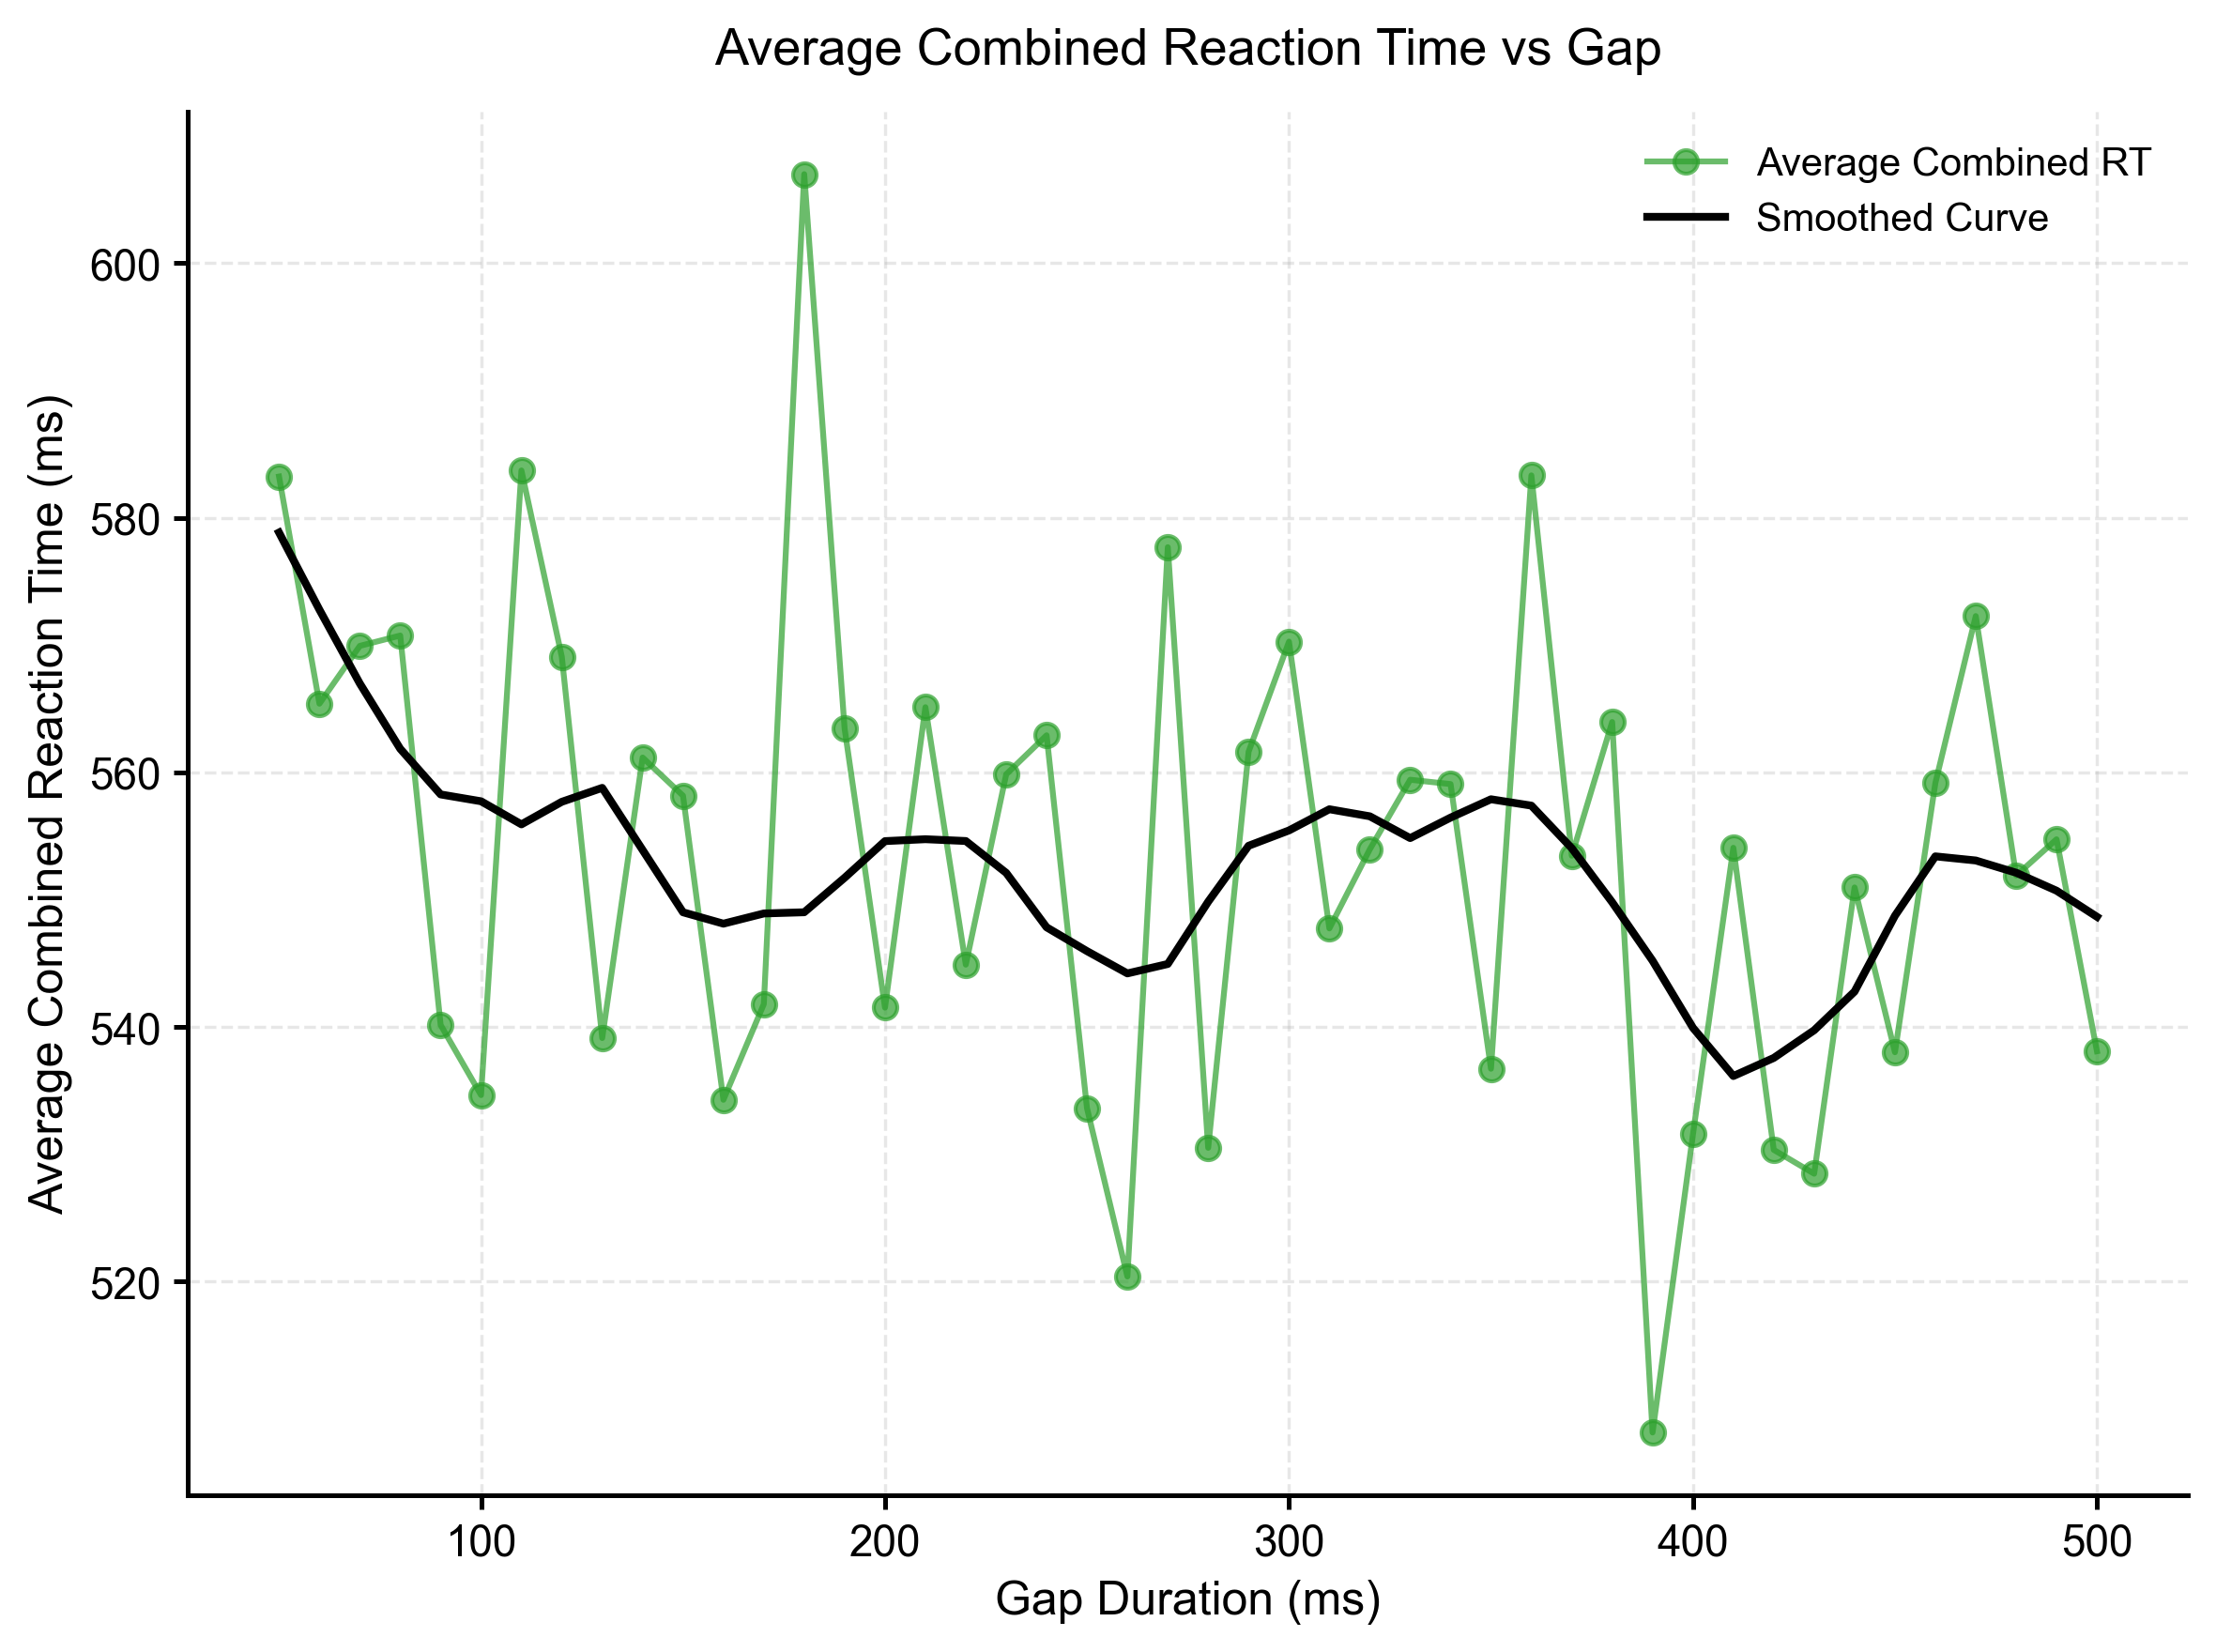


Saved plot to: graphs/avg_combined_rt_vs_gap.png


In [19]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from statsmodels.nonparametric.smoothers_lowess import lowess

# ---------------- PLOT STYLE ---------------- #
plt.rcParams.update({
    'font.family': 'Arial',
    'font.size': 11,
    'axes.labelsize': 12,
    'axes.titlesize': 13,
    'xtick.labelsize': 11,
    'ytick.labelsize': 11,
    'legend.fontsize': 10,
    'figure.dpi': 300,
    'savefig.dpi': 300,
    'axes.linewidth': 1.2,
    'xtick.major.width': 1.2,
    'ytick.major.width': 1.2
})

# ---------------- SMART PROJECT ROOT DETECTION ---------------- #
cwd = Path.cwd()
for parent in [cwd] + list(cwd.parents):
    if parent.name == "Temporal-Attention":
        project_root = parent
        break

base_path = project_root / "data" / "averaged"
print(f"Using base path: {base_path}")

# ---------------- PARTICIPANT DETECTION ---------------- #
participants = sorted([p.name for p in base_path.iterdir() if p.is_dir()])
participants.remove("manaswini")
print(f"Detected participants: {participants}")

combined_data = []

# ---------------- LOAD AND MERGE ---------------- #
for participant in participants:
    csv_path = base_path / participant / f"{participant}_combinedavg.csv"
    
    if not csv_path.exists():
        continue
    
    df = pd.read_csv(csv_path)
    
    rt_col = next((c for c in df.columns if 'Combined' in c and 'RT' in c), None)
    
    if 'Gap' not in df.columns or rt_col is None:
        continue

    df = df[['Gap', rt_col]].copy()
    df.rename(columns={rt_col: participant}, inplace=True)
    combined_data.append(df)

if not combined_data:
    raise ValueError("No valid participant data found. Check file paths and CSV structure.")

# ---------------- MERGE ---------------- #
merged_df = combined_data[0]
for df in combined_data[1:]:
    merged_df = pd.merge(merged_df, df, on='Gap', how='inner')

print("Columns after merge:", merged_df.columns.tolist())

# ---------------- COMPUTE AVERAGE ---------------- #
valid_participants = [c for c in merged_df.columns if c in participants]
merged_df['AvgCombinedRT'] = merged_df[valid_participants].mean(axis=1)

# ---------------- SMOOTHING ---------------- #
smoothed = lowess(merged_df['AvgCombinedRT'], merged_df['Gap'], frac=0.2)

# ---------------- PLOT ---------------- #
fig, ax = plt.subplots(figsize=(8, 6))
color_avg = plt.get_cmap("tab10")(2)

ax.plot(merged_df['Gap'], merged_df['AvgCombinedRT'], 
        marker='o', color=color_avg, alpha=0.7, label='Average Combined RT')
ax.plot(smoothed[:, 0], smoothed[:, 1], 
        color='black', linewidth=2, label='Smoothed Curve')

ax.set_title('Average Combined Reaction Time vs Gap', pad=12)
ax.set_xlabel('Gap Duration (ms)')
ax.set_ylabel('Average Combined Reaction Time (ms)')

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.grid(True, linestyle='--', alpha=0.3)
ax.legend(frameon=False, loc='best')

plt.tight_layout()

# Save output
plots_dir = project_root / "graphs"
plots_dir.mkdir(parents=True, exist_ok=True)
save_path = plots_dir / "avg_combined_rt_vs_gap.png"
plt.savefig(save_path, bbox_inches='tight', format='png')

plt.show()
print(f"\nSaved plot to: {save_path.relative_to(project_root)}")


Detected participants: ['addie', 'all_combined', 'angelyn', 'combined', 'jamshed', 'jill', 'lila', 'mahalakshmi', 'manaswini', 'navya', 'richard', 'sree', 'vidhya']
No CSV found for all_combined, skipping...
No CSV found for combined, skipping...
Columns after merge: ['Gap', 'addie', 'angelyn', 'jamshed', 'jill', 'lila', 'mahalakshmi', 'manaswini', 'navya', 'richard', 'sree', 'vidhya']


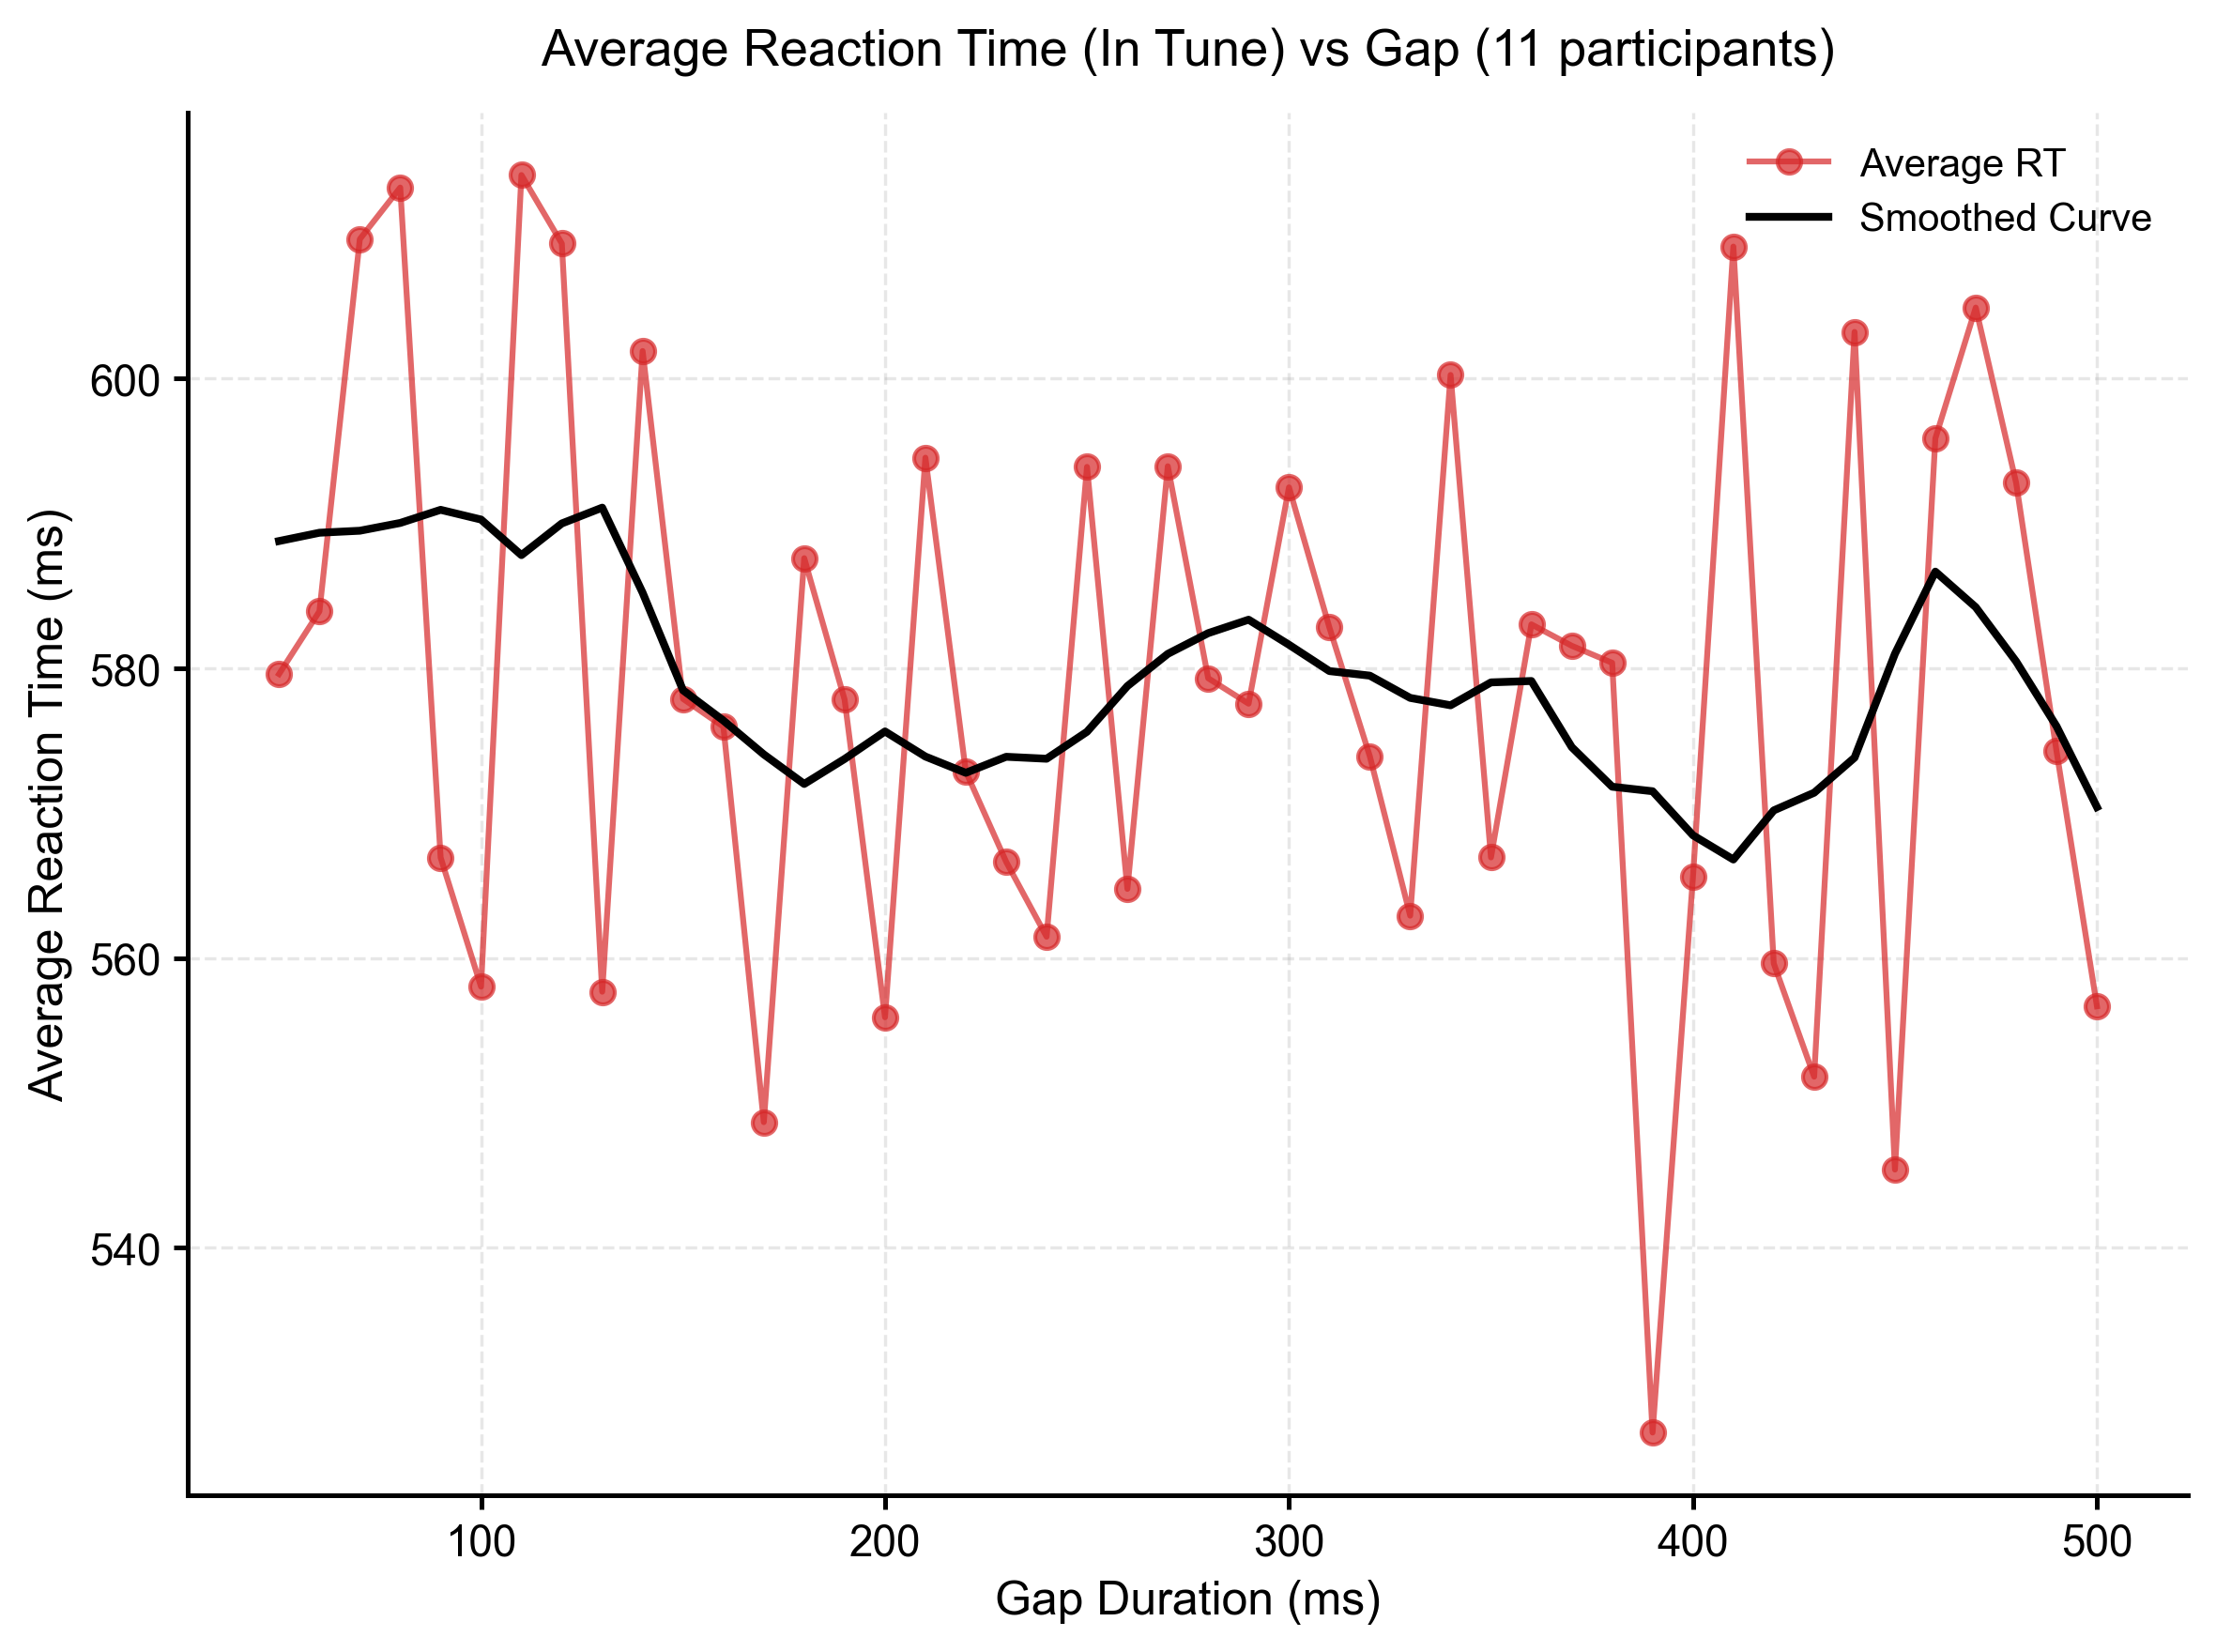


Saved plot to: graphs/avg_in_tune_reaction_time_vs_gap.png


In [20]:
participants = sorted([p.name for p in base_path.iterdir() if p.is_dir()])
print(f"Detected participants: {participants}")

combined_data = []

# ---------------- LOAD AND MERGE ---------------- #
for participant in participants:
    csv_path = base_path / participant / f"{participant}_inavg.csv"
    if not csv_path.exists():
        print(f"No CSV found for {participant}, skipping...")
        continue
    df = pd.read_csv(csv_path)

    # find column like addieInAveRT or angelynInAveRT
    rt_col = next((c for c in df.columns if "InAveRT" in c), None)
    if "Gap" not in df.columns or rt_col is None:
        print(f"Missing required columns in {participant}, skipping...")
        continue

    df = df[["Gap", rt_col]].copy()
    df.rename(columns={rt_col: participant}, inplace=True)
    combined_data.append(df)

if not combined_data:
    raise ValueError("No valid participant data found.")

# ---------------- MERGE ---------------- #
merged_df = combined_data[0]
for df in combined_data[1:]:
    merged_df = pd.merge(merged_df, df, on="Gap", how="inner")

print("Columns after merge:", merged_df.columns.tolist())

# ---------------- COMPUTE AVERAGE ---------------- #
valid_participants = [c for c in merged_df.columns if c in participants]
merged_df["InAvgCombinedRT"] = merged_df[valid_participants].mean(axis=1)

# ---------------- SMOOTH ---------------- #
smoothed = lowess(merged_df["InAvgCombinedRT"], merged_df["Gap"], frac=0.2)

# ---------------- PLOT ---------------- #
fig, ax = plt.subplots(figsize=(8, 6))
color_avg = plt.get_cmap("tab10")(3)

ax.plot(merged_df["Gap"], merged_df["InAvgCombinedRT"], marker="o", color=color_avg, alpha=0.7, label="Average RT")
ax.plot(smoothed[:, 0], smoothed[:, 1], color="black", linewidth=2, label="Smoothed Curve")

ax.set_title(f"Average Reaction Time (In Tune) vs Gap ({len(valid_participants)} participants)", pad=12)
ax.set_xlabel("Gap Duration (ms)")
ax.set_ylabel("Average Reaction Time (ms)")

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.grid(True, linestyle="--", alpha=0.3)
ax.legend(frameon=False, loc="best")

plt.tight_layout()

# ---------------- SAVE ---------------- #
plots_dir = project_root / "graphs"
plots_dir.mkdir(parents=True, exist_ok=True)
save_path = plots_dir / "avg_in_tune_reaction_time_vs_gap.png"
plt.savefig(save_path, bbox_inches="tight", format="png")

plt.show()
print(f"\nSaved plot to: {save_path.relative_to(project_root)}")


Detected participants: ['addie', 'all_combined', 'angelyn', 'combined', 'jamshed', 'jill', 'lila', 'mahalakshmi', 'manaswini', 'navya', 'richard', 'sree', 'vidhya']
No CSV found for all_combined, skipping...
No CSV found for combined, skipping...
Columns after merge: ['Gap', 'addie', 'angelyn', 'jamshed', 'jill', 'lila', 'mahalakshmi', 'manaswini', 'navya', 'richard', 'sree', 'vidhya']


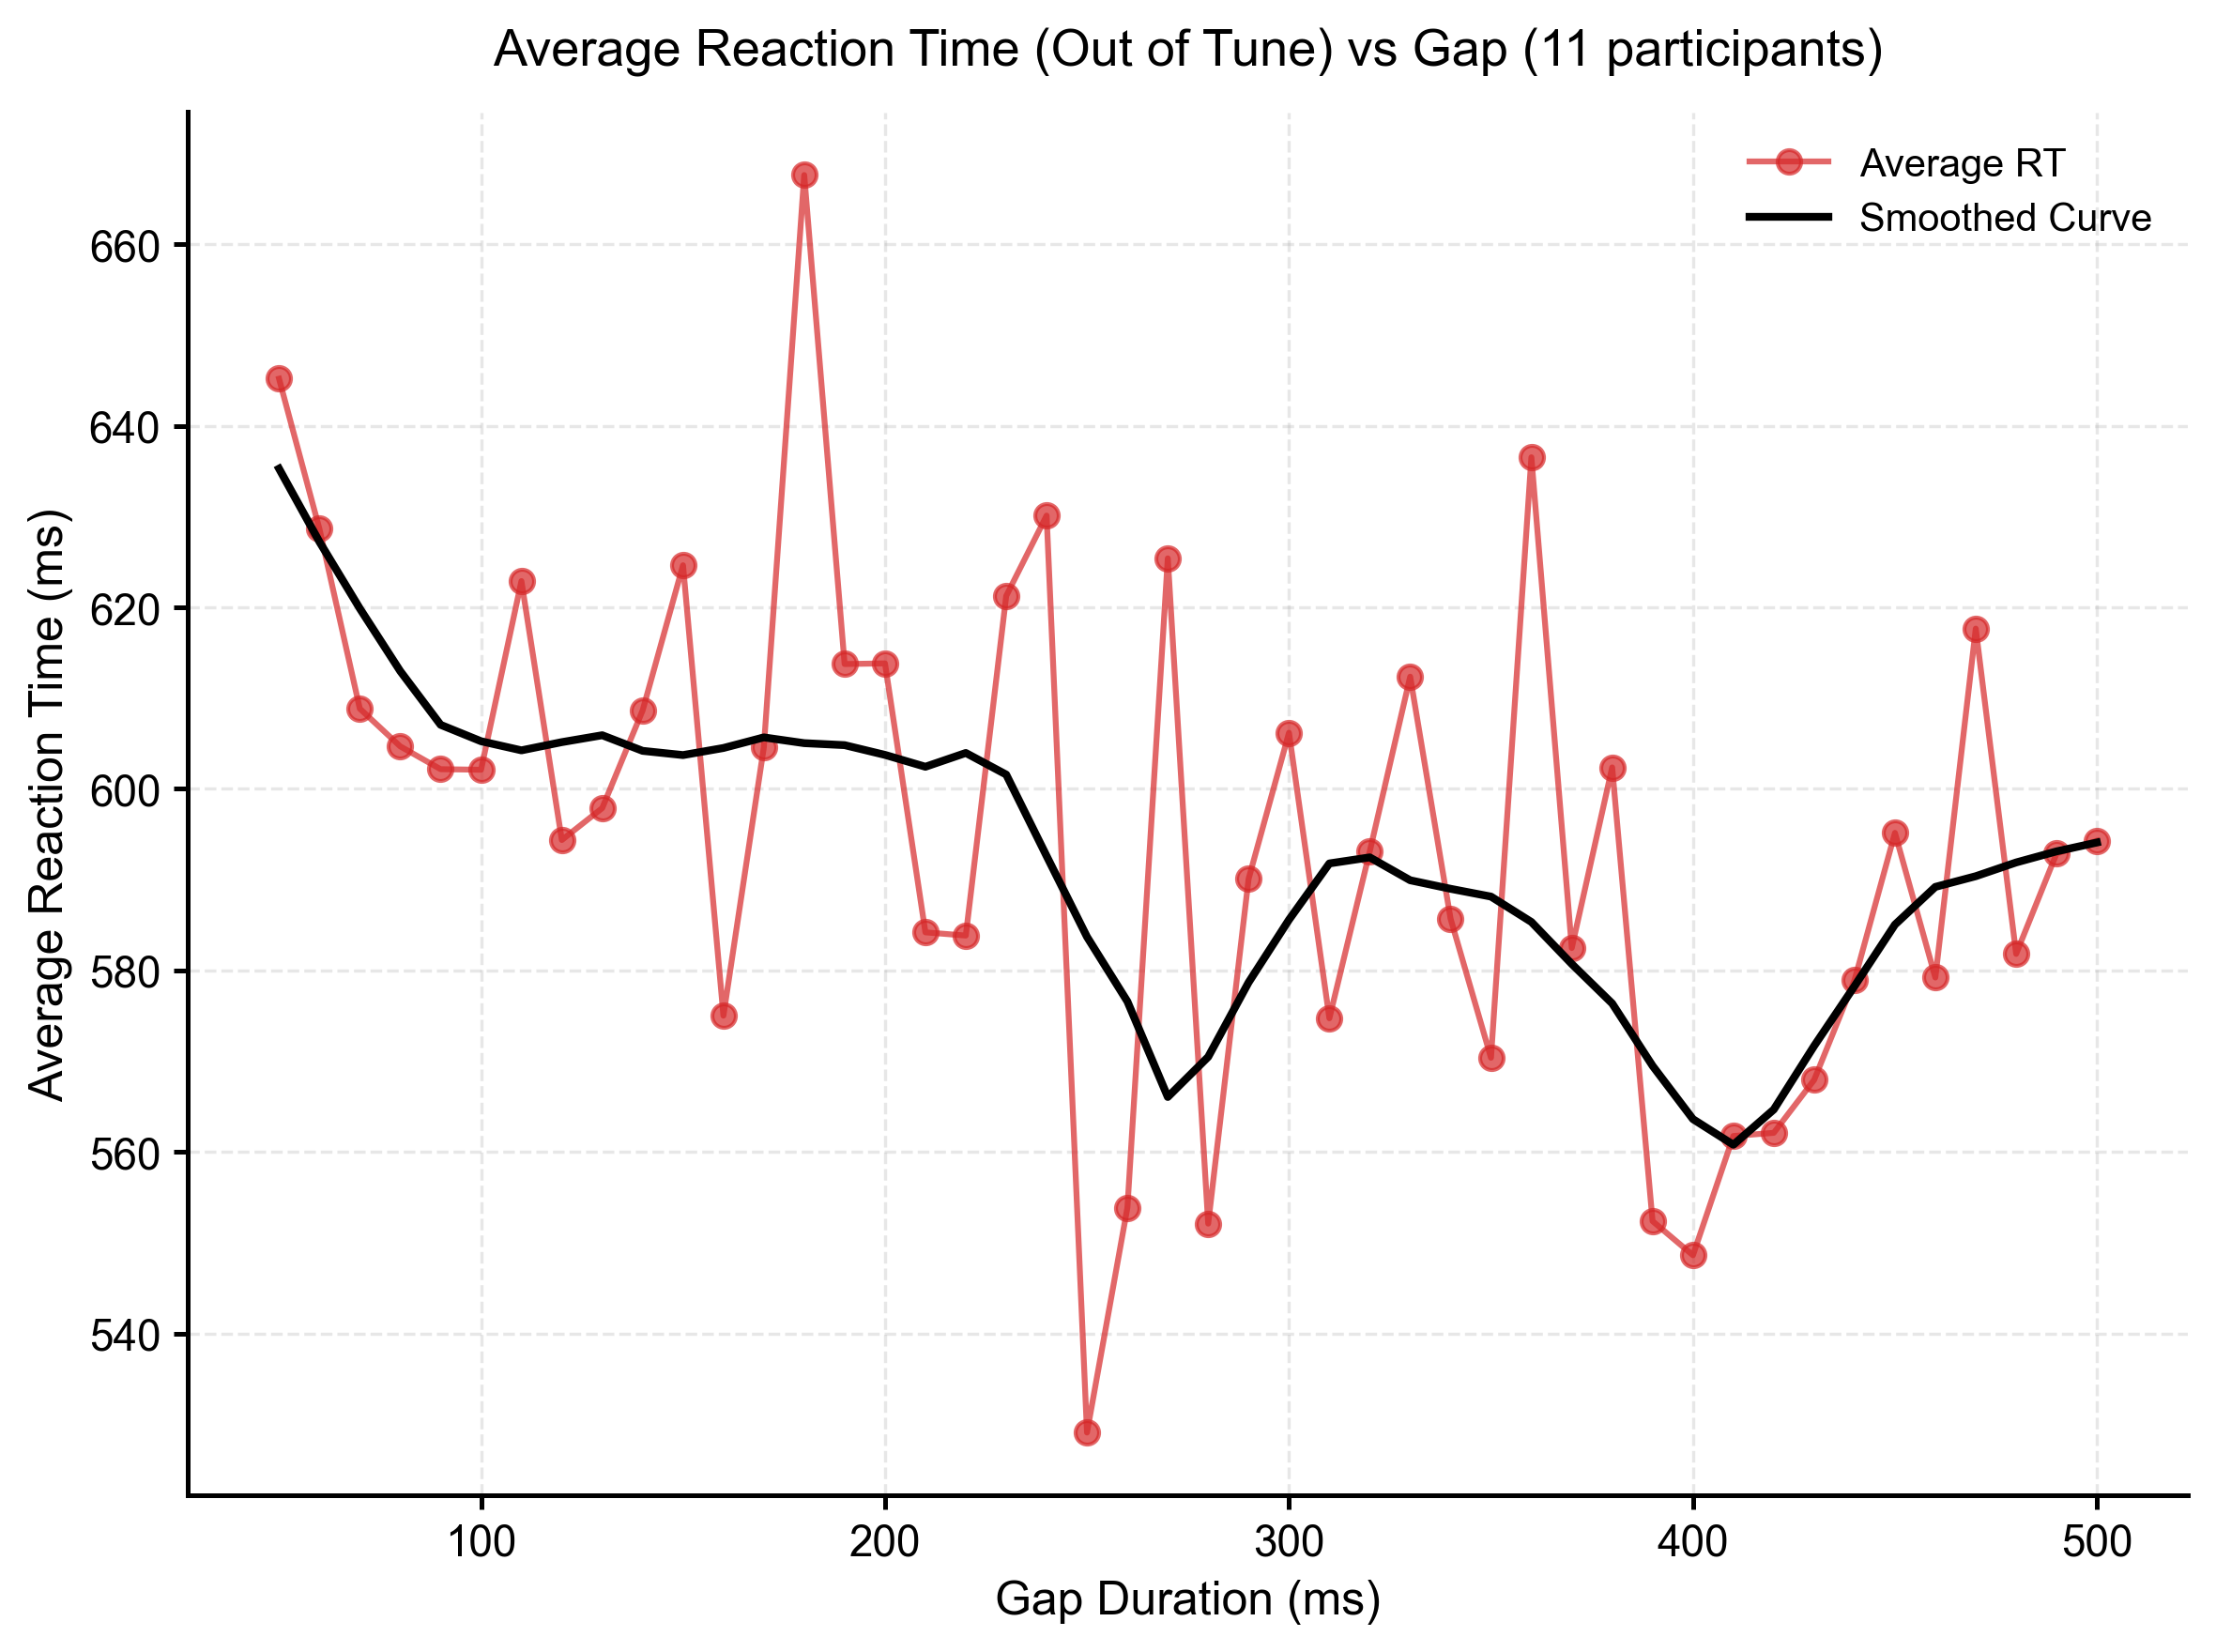


Saved plot to: graphs/avg_out_of_tune_reaction_time_vs_gap.png


In [21]:
participants = sorted([p.name for p in base_path.iterdir() if p.is_dir()])
print(f"Detected participants: {participants}")

combined_data = []

# ---------------- LOAD AND MERGE ---------------- #
for participant in participants:
    csv_path = base_path / participant / f"{participant}_outavg.csv"
    if not csv_path.exists():
        print(f"No CSV found for {participant}, skipping...")
        continue
    df = pd.read_csv(csv_path)

    # find column like addieInAveRT or angelynInAveRT
    rt_col = next((c for c in df.columns if "OutAveRT" in c), None)
    if "Gap" not in df.columns or rt_col is None:
        print(f"Missing required columns in {participant}, skipping...")
        continue

    df = df[["Gap", rt_col]].copy()
    df.rename(columns={rt_col: participant}, inplace=True)
    combined_data.append(df)

if not combined_data:
    raise ValueError("No valid participant data found.")

# ---------------- MERGE ---------------- #
merged_df = combined_data[0]
for df in combined_data[1:]:
    merged_df = pd.merge(merged_df, df, on="Gap", how="inner")

print("Columns after merge:", merged_df.columns.tolist())

# ---------------- COMPUTE AVERAGE ---------------- #
valid_participants = [c for c in merged_df.columns if c in participants]
merged_df["OutAvgCombinedRT"] = merged_df[valid_participants].mean(axis=1)

smoothed = lowess(merged_df["OutAvgCombinedRT"], merged_df["Gap"], frac=0.2)

# ---------------- PLOT ---------------- #
fig, ax = plt.subplots(figsize=(8, 6))
color_avg = plt.get_cmap("tab10")(3)

ax.plot(merged_df["Gap"], merged_df["OutAvgCombinedRT"], marker="o", color=color_avg, alpha=0.7, label="Average RT")
ax.plot(smoothed[:, 0], smoothed[:, 1], color="black", linewidth=2, label="Smoothed Curve")

ax.set_title(f"Average Reaction Time (Out of Tune) vs Gap ({len(valid_participants)} participants)", pad=12)
ax.set_xlabel("Gap Duration (ms)")
ax.set_ylabel("Average Reaction Time (ms)")

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.grid(True, linestyle="--", alpha=0.3)
ax.legend(frameon=False, loc="best")

plt.tight_layout()

# ---------------- SAVE ---------------- #
plots_dir = project_root / "graphs"
plots_dir.mkdir(parents=True, exist_ok=True)
save_path = plots_dir / "avg_out_of_tune_reaction_time_vs_gap.png"
plt.savefig(save_path, bbox_inches="tight", format="png")

plt.show()
print(f"\nSaved plot to: {save_path.relative_to(project_root)}")


Loading and transforming participant data...
Found 11 participants
In-tune data points: 506
Out-of-tune data points: 506

Computing group averages...
In-tune average - Gap range: 50-500
Out-of-tune average - Gap range: 50-500

Applying LOWESS smoothing...


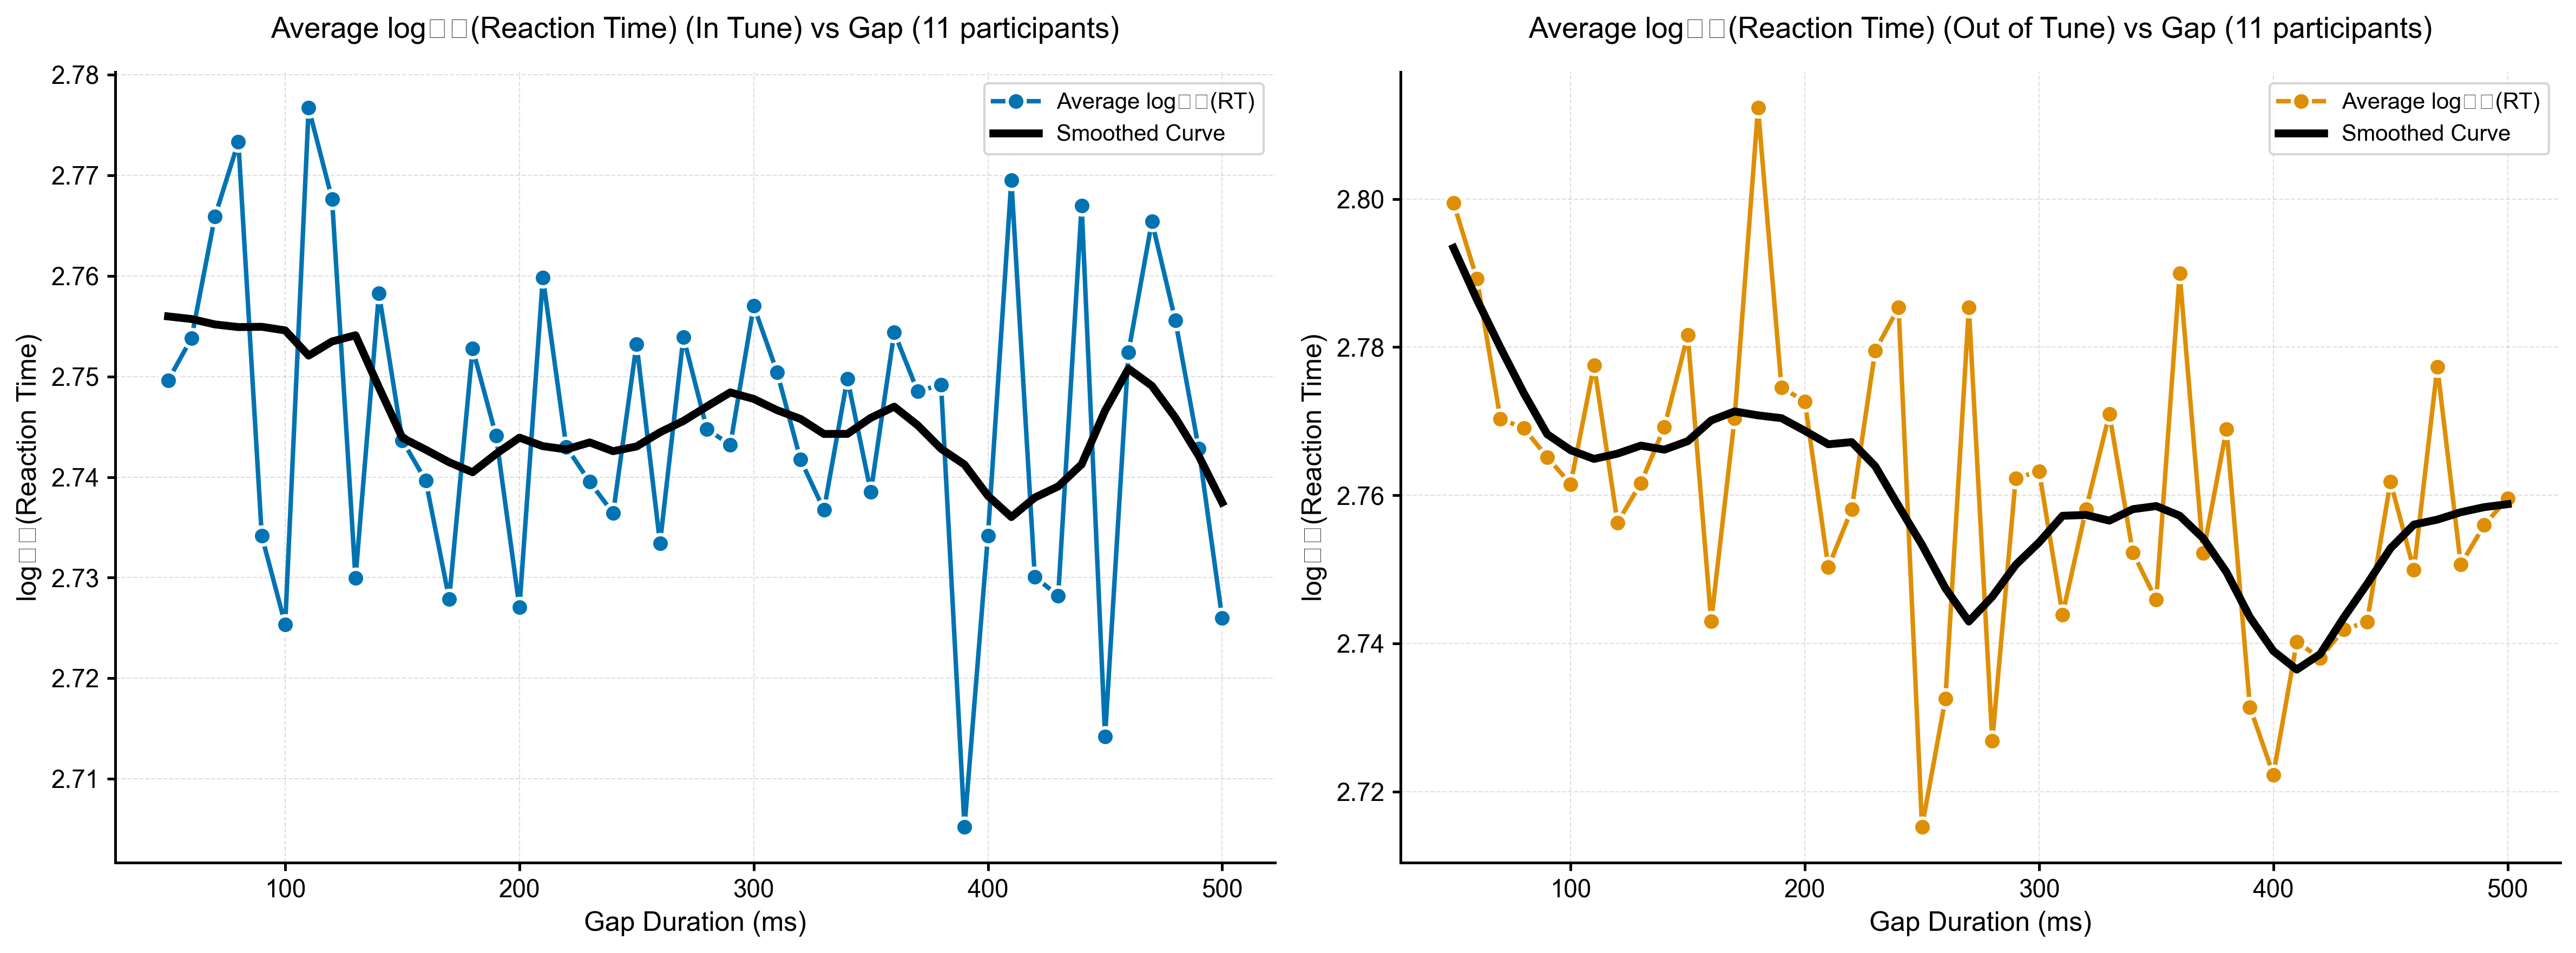


GROUP STATISTICS (LOG SCALE)

In-Tune:
  Mean log₁₀(RT): 2.7455
  Equivalent RT: 556.57 ms
  Range: 2.7052 - 2.7767

Out-of-Tune:
  Mean log₁₀(RT): 2.7606
  Equivalent RT: 576.22 ms
  Range: 2.7153 - 2.8123


In [22]:
plt.rcParams['font.family'] = 'Arial'
plt.rcParams['font.size'] = 11
plt.rcParams['axes.labelsize'] = 12
plt.rcParams['axes.titlesize'] = 13
plt.rcParams['figure.dpi'] = 300
plt.rcParams['savefig.dpi'] = 300

def load_and_process_all_participants(averaged_dir='/Users/vidhyakshayakannan/Documents/Temporal-Attention/data/averaged'):
    """
    Load all participant data, apply log transform, and prepare for averaging.
    """
    averaged_path = Path(averaged_dir)
    participant_folders = [f for f in averaged_path.iterdir() if f.is_dir() and f.name != 'all_combined' and f.name != 'combined']
    
    print(f"Found {len(participant_folders)} participants")
    
    # Store all participant data
    all_intune_data = []
    all_outtune_data = []
    
    for participant_folder in sorted(participant_folders):
        participant_name = participant_folder.name
        
        # Load in-tune data
        intune_file = participant_folder / f"{participant_name}_inavg.csv"
        if intune_file.exists():
            df = pd.read_csv(intune_file)
            rt_col = [col for col in df.columns if 'AveRT' in col][0]
            df['log10_RT'] = np.log10(df[rt_col])
            df['Participant'] = participant_name
            all_intune_data.append(df[['Gap', 'log10_RT', 'Participant']])
        
        # Load out-of-tune data
        outtune_file = participant_folder / f"{participant_name}_outavg.csv"
        if outtune_file.exists():
            df = pd.read_csv(outtune_file)
            rt_col = [col for col in df.columns if 'AveRT' in col][0]
            
            # Apply log10 transform
            df['log10_RT'] = np.log10(df[rt_col])
            df['Participant'] = participant_name
            all_outtune_data.append(df[['Gap', 'log10_RT', 'Participant']])
    
    # Combine all participants
    intune_combined = pd.concat(all_intune_data, ignore_index=True)
    outtune_combined = pd.concat(all_outtune_data, ignore_index=True)
    
    print(f"In-tune data points: {len(intune_combined)}")
    print(f"Out-of-tune data points: {len(outtune_combined)}")
    
    return intune_combined, outtune_combined

def compute_group_average(df):
    """
    Compute average log10(RT) across all participants for each gap.
    """
    group_avg = df.groupby('Gap')['log10_RT'].mean().reset_index()
    group_avg.columns = ['Gap', 'Avg_log10_RT']
    return group_avg

def apply_lowess_smoothing(df, frac=0.2):
    """
    Apply LOWESS smoothing to the averaged data.
    """
    smoothed = lowess(df['Avg_log10_RT'], df['Gap'], frac=frac)
    smoothed_df = pd.DataFrame(smoothed, columns=['Gap', 'Smoothed_log10_RT'])
    return smoothed_df

# Load all participant data
print("Loading and transforming participant data...")
intune_all, outtune_all = load_and_process_all_participants()

# Compute group averages
print("\nComputing group averages...")
intune_avg = compute_group_average(intune_all)
outtune_avg = compute_group_average(outtune_all)

print(f"In-tune average - Gap range: {intune_avg['Gap'].min()}-{intune_avg['Gap'].max()}")
print(f"Out-of-tune average - Gap range: {outtune_avg['Gap'].min()}-{outtune_avg['Gap'].max()}")

# Apply LOWESS smoothing
print("\nApplying LOWESS smoothing...")
intune_smoothed = apply_lowess_smoothing(intune_avg, frac=0.2)
outtune_smoothed = apply_lowess_smoothing(outtune_avg, frac=0.2)

# Count participants
n_participants = len(intune_all['Participant'].unique())

# Create separate plots for In-Tune and Out-of-Tune
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# ===== IN-TUNE PLOT =====
# Plot average log10(RT) with markers
ax1.plot(intune_avg['Gap'], intune_avg['Avg_log10_RT'], 
         color='#0173B2', linewidth=2, marker='o', markersize=8,
         markerfacecolor='#0173B2', markeredgecolor='white', markeredgewidth=1.5,
         label='Average log₁₀(RT)', zorder=3)

# Plot smoothed curve (solid black line)
ax1.plot(intune_smoothed['Gap'], intune_smoothed['Smoothed_log10_RT'], 
         color='black', linewidth=3.5, linestyle='-', 
         label='Smoothed Curve', zorder=4)

ax1.set_xlabel('Gap Duration (ms)', fontweight='normal')
ax1.set_ylabel('log₁₀(Reaction Time)', fontweight='normal')
ax1.set_title(f'Average log₁₀(Reaction Time) (In Tune) vs Gap ({n_participants} participants)', 
              fontweight='normal', pad=15)
ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)
ax1.grid(True, alpha=0.25, linestyle='--', linewidth=0.5, color='gray')
ax1.legend(frameon=True, loc='best', fontsize=10)

# ===== OUT-OF-TUNE PLOT =====
# Plot average log10(RT) with markers
ax2.plot(outtune_avg['Gap'], outtune_avg['Avg_log10_RT'], 
         color='#DE8F05', linewidth=2, marker='o', markersize=8,
         markerfacecolor='#DE8F05', markeredgecolor='white', markeredgewidth=1.5,
         label='Average log₁₀(RT)', zorder=3)

# Plot smoothed curve (solid black line)
ax2.plot(outtune_smoothed['Gap'], outtune_smoothed['Smoothed_log10_RT'], 
         color='black', linewidth=3.5, linestyle='-', 
         label='Smoothed Curve', zorder=4)

ax2.set_xlabel('Gap Duration (ms)', fontweight='normal')
ax2.set_ylabel('log₁₀(Reaction Time)', fontweight='normal')
ax2.set_title(f'Average log₁₀(Reaction Time) (Out of Tune) vs Gap ({n_participants} participants)', 
              fontweight='normal', pad=15)
ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)
ax2.grid(True, alpha=0.25, linestyle='--', linewidth=0.5, color='gray')
ax2.legend(frameon=True, loc='best', fontsize=10)

plt.tight_layout()
plt.savefig('group_average_log_rt_separate.pdf', format='pdf', bbox_inches='tight')
plt.savefig('group_average_log_rt_separate.png', format='png', bbox_inches='tight')
plt.show()

# Print statistics
print("\n" + "="*60)
print("GROUP STATISTICS (LOG SCALE)")
print("="*60)
print(f"\nIn-Tune:")
print(f"  Mean log₁₀(RT): {intune_avg['Avg_log10_RT'].mean():.4f}")
print(f"  Equivalent RT: {10**intune_avg['Avg_log10_RT'].mean():.2f} ms")
print(f"  Range: {intune_avg['Avg_log10_RT'].min():.4f} - {intune_avg['Avg_log10_RT'].max():.4f}")

print(f"\nOut-of-Tune:")
print(f"  Mean log₁₀(RT): {outtune_avg['Avg_log10_RT'].mean():.4f}")
print(f"  Equivalent RT: {10**outtune_avg['Avg_log10_RT'].mean():.2f} ms")
print(f"  Range: {outtune_avg['Avg_log10_RT'].min():.4f} - {outtune_avg['Avg_log10_RT'].max():.4f}")

Loading and transforming participant data...
Found 10 participants
In-tune data points: 460
Out-of-tune data points: 460

Computing group averages...
In-tune average - Gap range: 50-500
Out-of-tune average - Gap range: 50-500

Applying LOWESS smoothing...


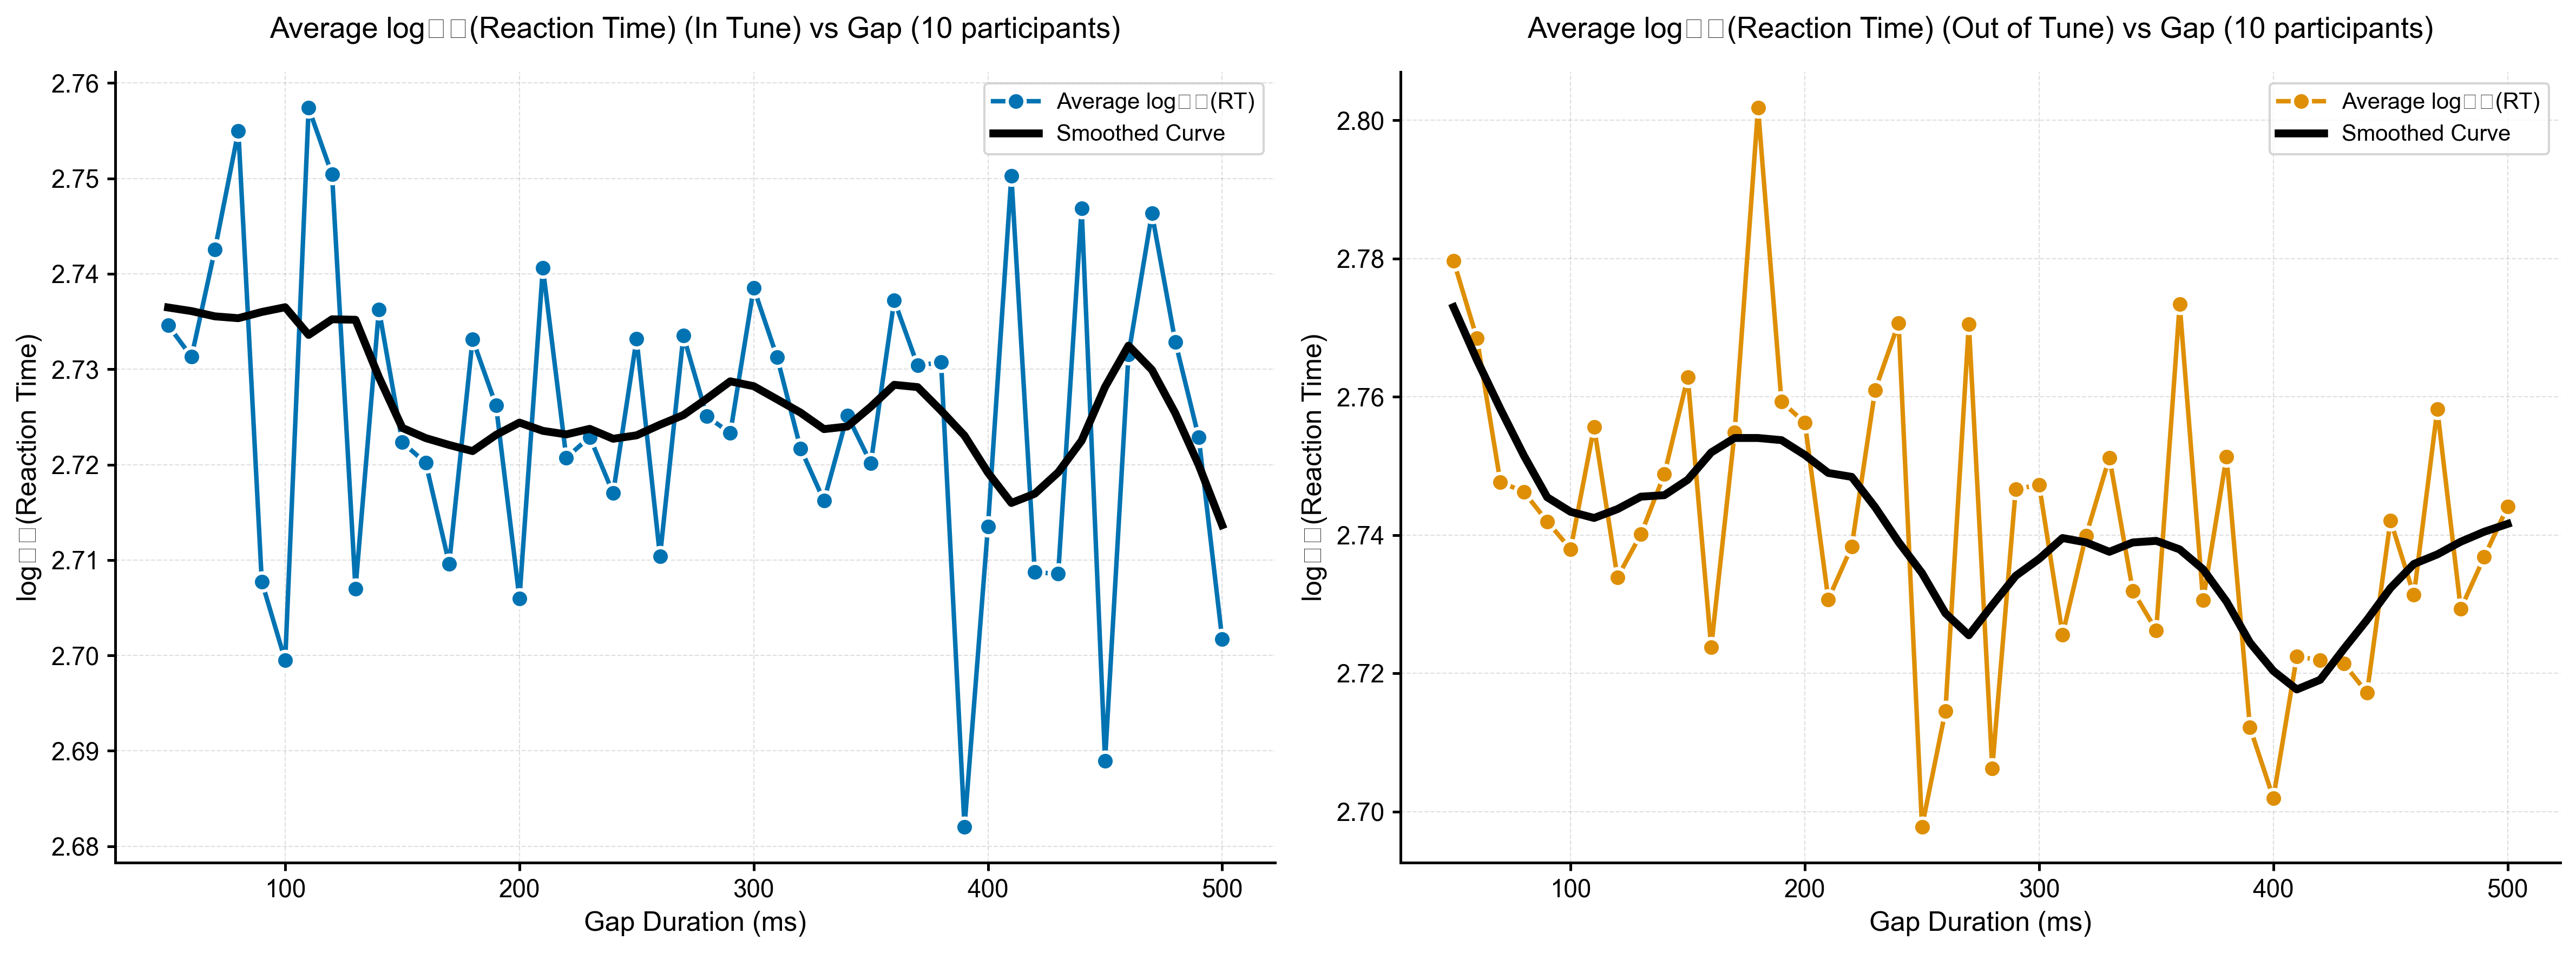


GROUP STATISTICS (LOG SCALE)

In-Tune:
  Mean log₁₀(RT): 2.7250
  Equivalent RT: 530.92 ms
  Range: 2.6820 - 2.7574

Out-of-Tune:
  Mean log₁₀(RT): 2.7416
  Equivalent RT: 551.53 ms
  Range: 2.6978 - 2.8018


In [23]:
plt.rcParams['font.family'] = 'Arial'
plt.rcParams['font.size'] = 11
plt.rcParams['axes.labelsize'] = 12
plt.rcParams['axes.titlesize'] = 13
plt.rcParams['figure.dpi'] = 300
plt.rcParams['savefig.dpi'] = 300

def load_and_process_all_participants(averaged_dir='/Users/vidhyakshayakannan/Documents/Temporal-Attention/data/averaged'):
    """
    Load all participant data, apply log transform, and prepare for averaging.
    """
    averaged_path = Path(averaged_dir)
    participant_folders = [f for f in averaged_path.iterdir() if f.is_dir() and f.name != 'all_combined' and f.name != 'combined' and f.name != 'manaswini']
    
    print(f"Found {len(participant_folders)} participants")
    
    # Store all participant data
    all_intune_data = []
    all_outtune_data = []
    
    for participant_folder in sorted(participant_folders):
        participant_name = participant_folder.name
        
        # Load in-tune data
        intune_file = participant_folder / f"{participant_name}_inavg.csv"
        if intune_file.exists():
            df = pd.read_csv(intune_file)
            rt_col = [col for col in df.columns if 'AveRT' in col][0]
            df['log10_RT'] = np.log10(df[rt_col])
            df['Participant'] = participant_name
            all_intune_data.append(df[['Gap', 'log10_RT', 'Participant']])
        
        # Load out-of-tune data
        outtune_file = participant_folder / f"{participant_name}_outavg.csv"
        if outtune_file.exists():
            df = pd.read_csv(outtune_file)
            rt_col = [col for col in df.columns if 'AveRT' in col][0]
            
            # Apply log10 transform
            df['log10_RT'] = np.log10(df[rt_col])
            df['Participant'] = participant_name
            all_outtune_data.append(df[['Gap', 'log10_RT', 'Participant']])
    
    # Combine all participants
    intune_combined = pd.concat(all_intune_data, ignore_index=True)
    outtune_combined = pd.concat(all_outtune_data, ignore_index=True)
    
    print(f"In-tune data points: {len(intune_combined)}")
    print(f"Out-of-tune data points: {len(outtune_combined)}")
    
    return intune_combined, outtune_combined

def compute_group_average(df):
    """
    Compute average log10(RT) across all participants for each gap.
    """
    group_avg = df.groupby('Gap')['log10_RT'].mean().reset_index()
    group_avg.columns = ['Gap', 'Avg_log10_RT']
    return group_avg

def apply_lowess_smoothing(df, frac=0.2):
    """
    Apply LOWESS smoothing to the averaged data.
    """
    smoothed = lowess(df['Avg_log10_RT'], df['Gap'], frac=frac)
    smoothed_df = pd.DataFrame(smoothed, columns=['Gap', 'Smoothed_log10_RT'])
    return smoothed_df

# Load all participant data
print("Loading and transforming participant data...")
intune_all, outtune_all = load_and_process_all_participants()

# Compute group averages
print("\nComputing group averages...")
intune_avg = compute_group_average(intune_all)
outtune_avg = compute_group_average(outtune_all)

print(f"In-tune average - Gap range: {intune_avg['Gap'].min()}-{intune_avg['Gap'].max()}")
print(f"Out-of-tune average - Gap range: {outtune_avg['Gap'].min()}-{outtune_avg['Gap'].max()}")

# Apply LOWESS smoothing
print("\nApplying LOWESS smoothing...")
intune_smoothed = apply_lowess_smoothing(intune_avg, frac=0.2)
outtune_smoothed = apply_lowess_smoothing(outtune_avg, frac=0.2)

# Count participants
n_participants = len(intune_all['Participant'].unique())

# Create separate plots for In-Tune and Out-of-Tune
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# ===== IN-TUNE PLOT =====
# Plot average log10(RT) with markers
ax1.plot(intune_avg['Gap'], intune_avg['Avg_log10_RT'], 
         color='#0173B2', linewidth=2, marker='o', markersize=8,
         markerfacecolor='#0173B2', markeredgecolor='white', markeredgewidth=1.5,
         label='Average log₁₀(RT)', zorder=3)

# Plot smoothed curve (solid black line)
ax1.plot(intune_smoothed['Gap'], intune_smoothed['Smoothed_log10_RT'], 
         color='black', linewidth=3.5, linestyle='-', 
         label='Smoothed Curve', zorder=4)

ax1.set_xlabel('Gap Duration (ms)', fontweight='normal')
ax1.set_ylabel('log₁₀(Reaction Time)', fontweight='normal')
ax1.set_title(f'Average log₁₀(Reaction Time) (In Tune) vs Gap ({n_participants} participants)', 
              fontweight='normal', pad=15)
ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)
ax1.grid(True, alpha=0.25, linestyle='--', linewidth=0.5, color='gray')
ax1.legend(frameon=True, loc='best', fontsize=10)

# ===== OUT-OF-TUNE PLOT =====
# Plot average log10(RT) with markers
ax2.plot(outtune_avg['Gap'], outtune_avg['Avg_log10_RT'], 
         color='#DE8F05', linewidth=2, marker='o', markersize=8,
         markerfacecolor='#DE8F05', markeredgecolor='white', markeredgewidth=1.5,
         label='Average log₁₀(RT)', zorder=3)

# Plot smoothed curve (solid black line)
ax2.plot(outtune_smoothed['Gap'], outtune_smoothed['Smoothed_log10_RT'], 
         color='black', linewidth=3.5, linestyle='-', 
         label='Smoothed Curve', zorder=4)

ax2.set_xlabel('Gap Duration (ms)', fontweight='normal')
ax2.set_ylabel('log₁₀(Reaction Time)', fontweight='normal')
ax2.set_title(f'Average log₁₀(Reaction Time) (Out of Tune) vs Gap ({n_participants} participants)', 
              fontweight='normal', pad=15)
ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)
ax2.grid(True, alpha=0.25, linestyle='--', linewidth=0.5, color='gray')
ax2.legend(frameon=True, loc='best', fontsize=10)

plt.tight_layout()
plt.savefig('group_average_log_rt_separate.pdf', format='pdf', bbox_inches='tight')
plt.savefig('group_average_log_rt_separate.png', format='png', bbox_inches='tight')
plt.show()

# Print statistics
print("\n" + "="*60)
print("GROUP STATISTICS (LOG SCALE)")
print("="*60)
print(f"\nIn-Tune:")
print(f"  Mean log₁₀(RT): {intune_avg['Avg_log10_RT'].mean():.4f}")
print(f"  Equivalent RT: {10**intune_avg['Avg_log10_RT'].mean():.2f} ms")
print(f"  Range: {intune_avg['Avg_log10_RT'].min():.4f} - {intune_avg['Avg_log10_RT'].max():.4f}")

print(f"\nOut-of-Tune:")
print(f"  Mean log₁₀(RT): {outtune_avg['Avg_log10_RT'].mean():.4f}")
print(f"  Equivalent RT: {10**outtune_avg['Avg_log10_RT'].mean():.2f} ms")
print(f"  Range: {outtune_avg['Avg_log10_RT'].min():.4f} - {outtune_avg['Avg_log10_RT'].max():.4f}")

Loading, transforming, and smoothing individual participant data...
Found 11 participants
In-tune smoothed data points: 506
Out-of-tune smoothed data points: 506

Computing group average of smoothed curves...
In-tune average - Gap range: 50.0-500.0
Out-of-tune average - Gap range: 50.0-500.0


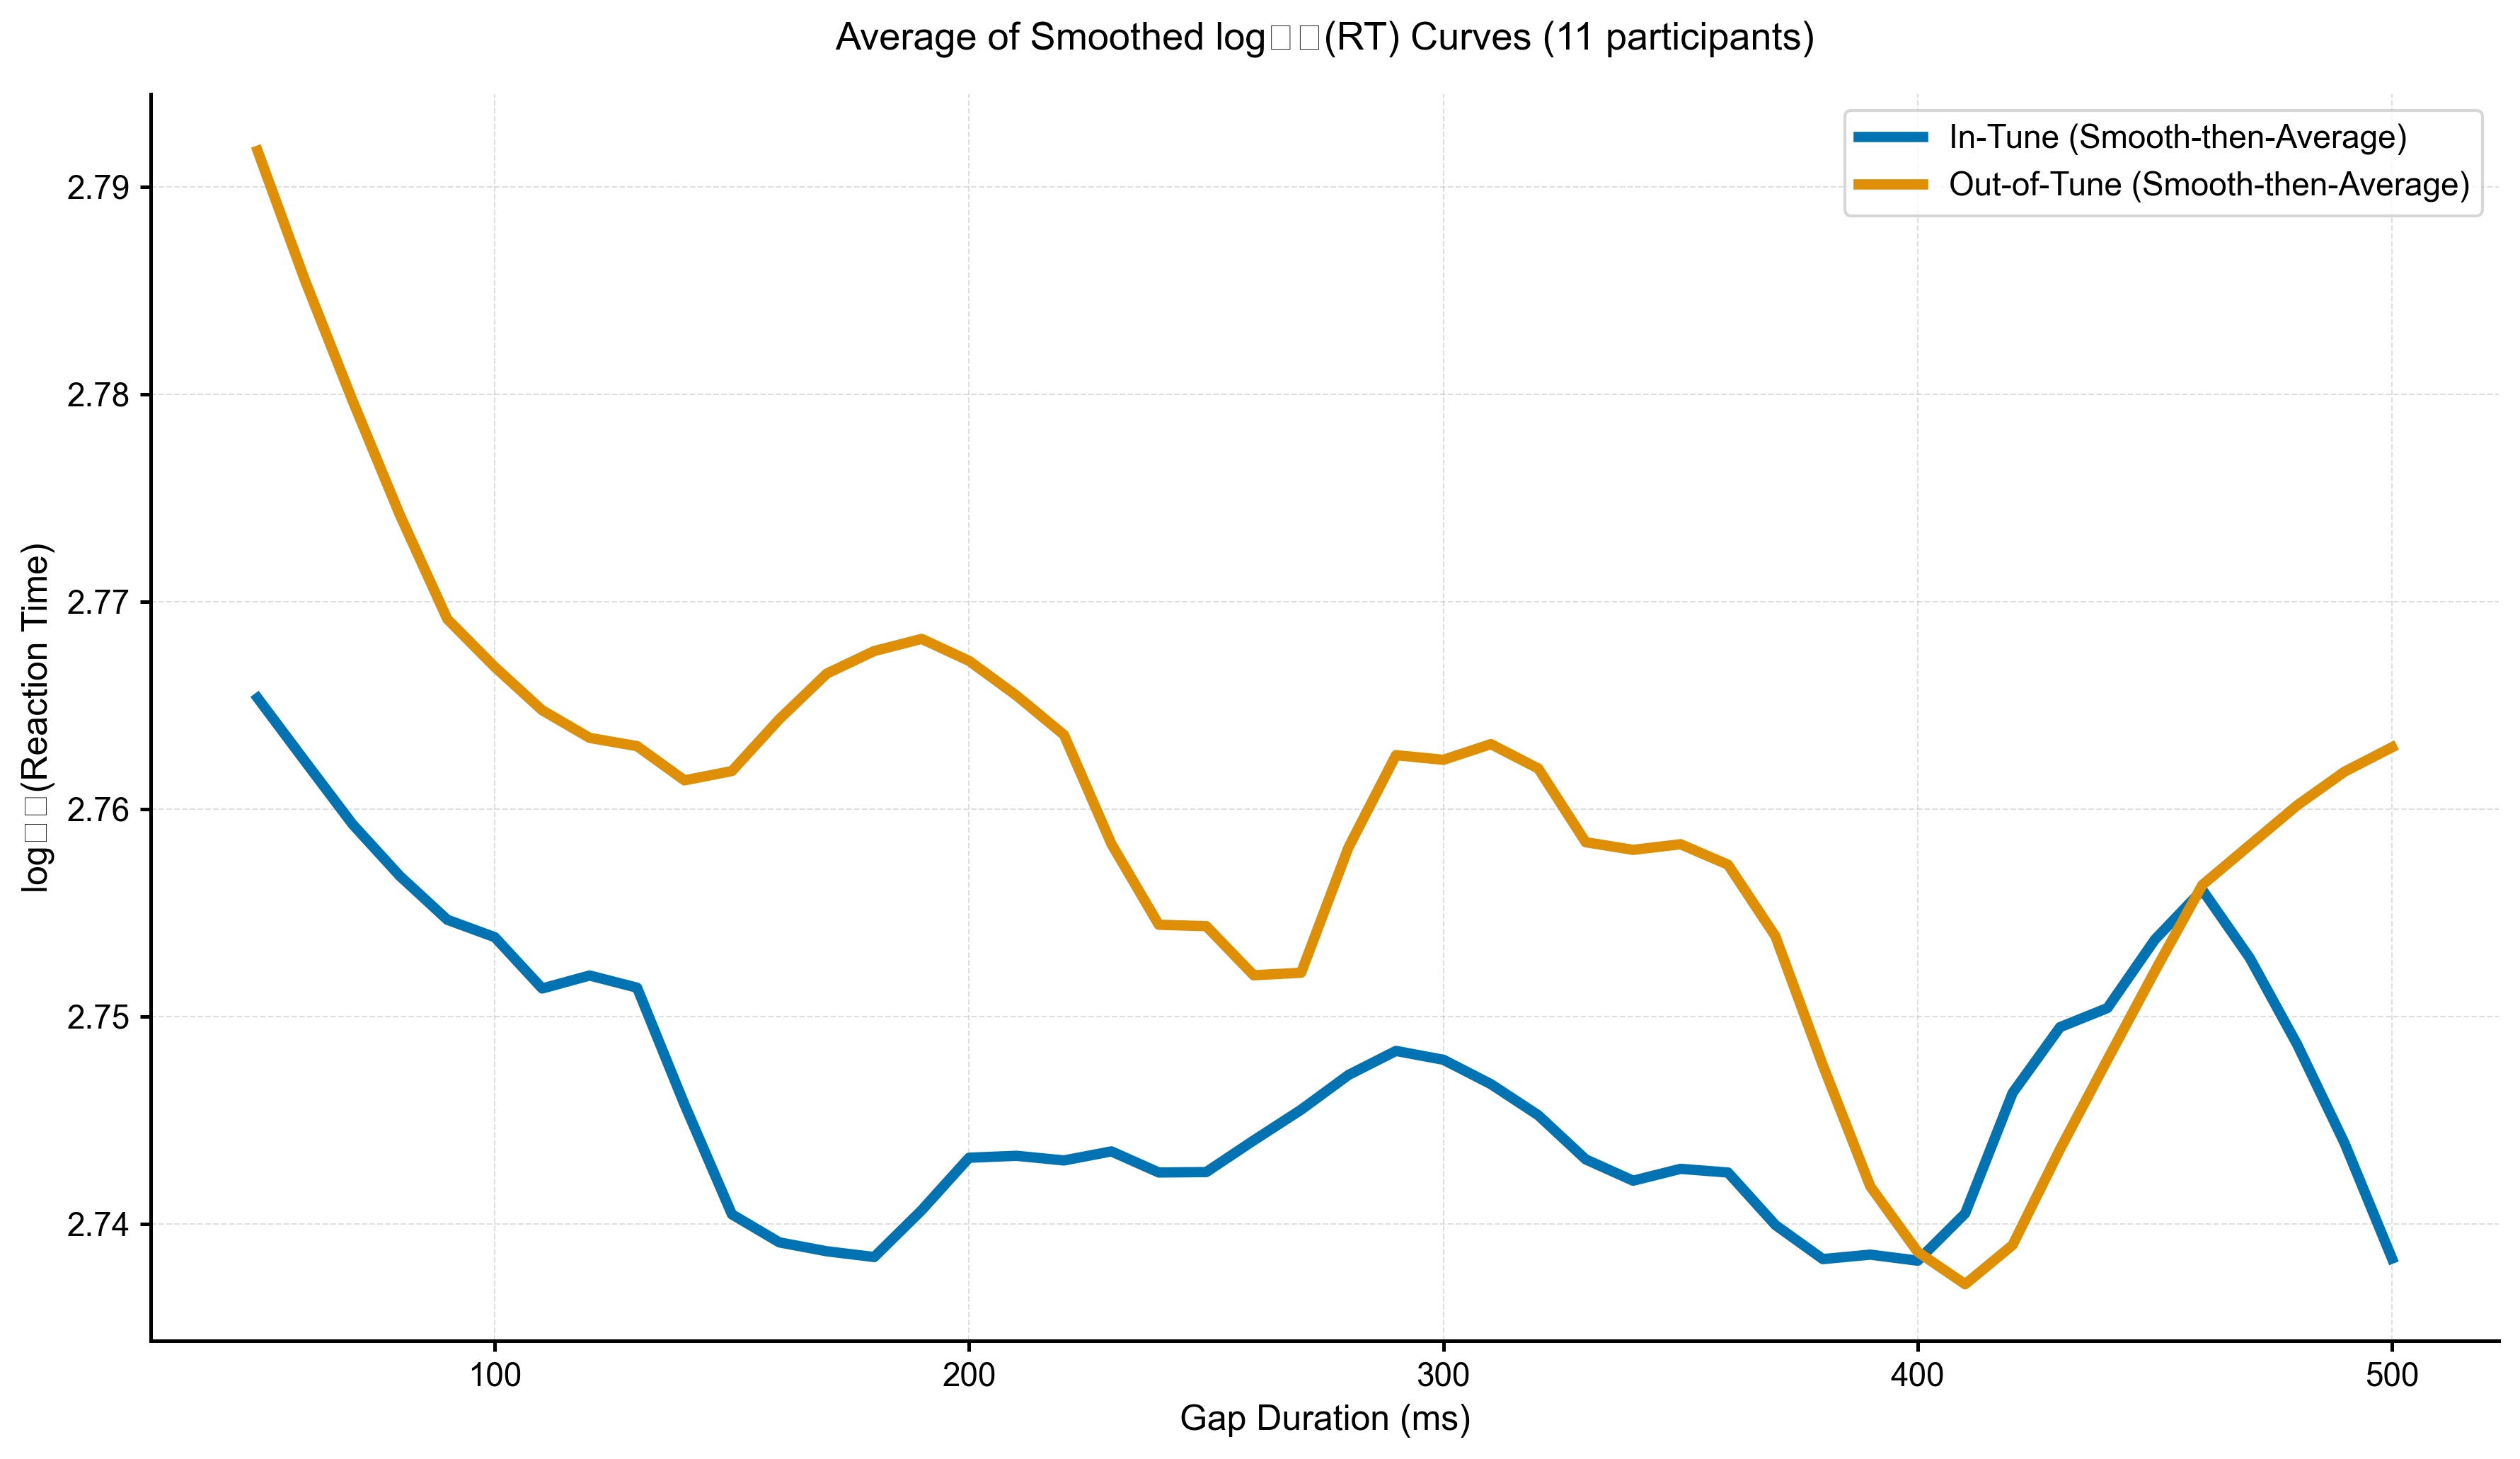


GROUP STATISTICS (SMOOTH-THEN-AVERAGE)

In-Tune:
  Mean log₁₀(RT): 2.7465
  Equivalent RT: 557.81 ms
  Range: 2.7382 - 2.7654

Out-of-Tune:
  Mean log₁₀(RT): 2.7599
  Equivalent RT: 575.36 ms
  Range: 2.7371 - 2.7917

Saved smooth-then-average results to: /Users/vidhyakshayakannan/Documents/Temporal-Attention/data/averaged/all_combined


In [24]:
plt.rcParams['font.family'] = 'Arial'
plt.rcParams['font.size'] = 11
plt.rcParams['axes.labelsize'] = 12
plt.rcParams['axes.titlesize'] = 13
plt.rcParams['figure.dpi'] = 300
plt.rcParams['savefig.dpi'] = 300

def load_and_smooth_individual_participants(averaged_dir='/Users/vidhyakshayakannan/Documents/Temporal-Attention/data/averaged', frac=0.2):
    """
    Load all participant data, apply log transform, then LOWESS smooth each participant individually.
    """
    averaged_path = Path(averaged_dir)
    participant_folders = [f for f in averaged_path.iterdir() if f.is_dir() and f.name != 'all_combined' and f.name != 'combined']
    
    print(f"Found {len(participant_folders)} participants")
    
    # Store smoothed data for all participants
    all_intune_smoothed = []
    all_outtune_smoothed = []
    
    for participant_folder in sorted(participant_folders):
        participant_name = participant_folder.name
        intune_file = participant_folder / f"{participant_name}_inavg.csv"
        if intune_file.exists():
            df = pd.read_csv(intune_file)
            rt_col = [col for col in df.columns if 'AveRT' in col][0]
            df['log10_RT'] = np.log10(df[rt_col])
            smoothed = lowess(df['log10_RT'], df['Gap'], frac=frac)
            smoothed_df = pd.DataFrame(smoothed, columns=['Gap', 'Smoothed_log10_RT'])
            smoothed_df['Participant'] = participant_name
            all_intune_smoothed.append(smoothed_df)
        
        outtune_file = participant_folder / f"{participant_name}_outavg.csv"
        if outtune_file.exists():
            df = pd.read_csv(outtune_file)
            rt_col = [col for col in df.columns if 'AveRT' in col][0]
            df['log10_RT'] = np.log10(df[rt_col])
            smoothed = lowess(df['log10_RT'], df['Gap'], frac=frac)
            smoothed_df = pd.DataFrame(smoothed, columns=['Gap', 'Smoothed_log10_RT'])
            smoothed_df['Participant'] = participant_name
            all_outtune_smoothed.append(smoothed_df)
    
    # Combine all participants' smoothed data
    intune_combined = pd.concat(all_intune_smoothed, ignore_index=True)
    outtune_combined = pd.concat(all_outtune_smoothed, ignore_index=True)
    
    print(f"In-tune smoothed data points: {len(intune_combined)}")
    print(f"Out-of-tune smoothed data points: {len(outtune_combined)}")
    
    return intune_combined, outtune_combined

def compute_group_average_from_smoothed(df):
    """
    Compute average across all participants' smoothed curves for each gap.
    """
    group_avg = df.groupby('Gap')['Smoothed_log10_RT'].mean().reset_index()
    group_avg.columns = ['Gap', 'Avg_Smoothed_log10_RT']
    return group_avg
print("Loading, transforming, and smoothing individual participant data...")
intune_smoothed_all, outtune_smoothed_all = load_and_smooth_individual_participants(frac=0.2)
print("\nComputing group average of smoothed curves...")
intune_avg_of_smoothed = compute_group_average_from_smoothed(intune_smoothed_all)
outtune_avg_of_smoothed = compute_group_average_from_smoothed(outtune_smoothed_all)

print(f"In-tune average - Gap range: {intune_avg_of_smoothed['Gap'].min()}-{intune_avg_of_smoothed['Gap'].max()}")
print(f"Out-of-tune average - Gap range: {outtune_avg_of_smoothed['Gap'].min()}-{outtune_avg_of_smoothed['Gap'].max()}")

# Count participants
n_participants = len(intune_smoothed_all['Participant'].unique())

# Create plot
fig, ax = plt.subplots(figsize=(12, 7))

# Plot In-Tune (average of smoothed curves)
ax.plot(intune_avg_of_smoothed['Gap'], intune_avg_of_smoothed['Avg_Smoothed_log10_RT'], 
        color='#0173B2', linewidth=3.5, linestyle='-',
        label='In-Tune (Smooth-then-Average)', zorder=4)

# Plot Out-of-Tune (average of smoothed curves)
ax.plot(outtune_avg_of_smoothed['Gap'], outtune_avg_of_smoothed['Avg_Smoothed_log10_RT'], 
        color='#DE8F05', linewidth=3.5, linestyle='-',
        label='Out-of-Tune (Smooth-then-Average)', zorder=4)

ax.set_xlabel('Gap Duration (ms)', fontweight='normal')
ax.set_ylabel('log₁₀(Reaction Time)', fontweight='normal')
ax.set_title(f'Average of Smoothed log₁₀(RT) Curves ({n_participants} participants)', 
             fontweight='normal', pad=15)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.grid(True, alpha=0.25, linestyle='--', linewidth=0.5, color='gray')
ax.legend(frameon=True, loc='best', fontsize=11)

plt.tight_layout()
plt.savefig('smooth_then_average_log_rt.pdf', format='pdf', bbox_inches='tight')
plt.savefig('smooth_then_average_log_rt.png', format='png', bbox_inches='tight')
plt.show()

print("\n" + "="*60)
print("GROUP STATISTICS (SMOOTH-THEN-AVERAGE)")
print("="*60)
print(f"\nIn-Tune:")
print(f"  Mean log₁₀(RT): {intune_avg_of_smoothed['Avg_Smoothed_log10_RT'].mean():.4f}")
print(f"  Equivalent RT: {10**intune_avg_of_smoothed['Avg_Smoothed_log10_RT'].mean():.2f} ms")
print(f"  Range: {intune_avg_of_smoothed['Avg_Smoothed_log10_RT'].min():.4f} - {intune_avg_of_smoothed['Avg_Smoothed_log10_RT'].max():.4f}")

print(f"\nOut-of-Tune:")
print(f"  Mean log₁₀(RT): {outtune_avg_of_smoothed['Avg_Smoothed_log10_RT'].mean():.4f}")
print(f"  Equivalent RT: {10**outtune_avg_of_smoothed['Avg_Smoothed_log10_RT'].mean():.2f} ms")
print(f"  Range: {outtune_avg_of_smoothed['Avg_Smoothed_log10_RT'].min():.4f} - {outtune_avg_of_smoothed['Avg_Smoothed_log10_RT'].max():.4f}")

# Save results
output_dir = Path('/Users/vidhyakshayakannan/Documents/Temporal-Attention/data/averaged/all_combined')
output_dir.mkdir(exist_ok=True)

intune_avg_of_smoothed.to_csv(output_dir / 'group_intune_smooth_then_avg.csv', index=False)
outtune_avg_of_smoothed.to_csv(output_dir / 'group_outtune_smooth_then_avg.csv', index=False)

print(f"\nSaved smooth-then-average results to: {output_dir}")